# 11. 개체 수준 종료사유 분석 + 보호소 격차 분해

> **v5 심화 분석 — 4가지 미해결 문제의 종합 해결**

| # | 미해결 문제 | 해결 방법 |
|---|-----------|----------|
| 1 | 수의사 인과효과 미확인 (PSM p=0.179, IV F=0.695) | **개체 수준 MNLogit/Cox PH** — 79만건 검정력 활용 |
| 2 | "안락사↓ ≠ 입양↑" 역설 (매개효과 음수 -2.20) | **대체결과 분석** — 안락사 감소분의 행방 추적 |
| 3 | 보호소 격차 확대 (σ-발산) 원인 미분해 | **Oaxaca-Blinder 분해** — 구성효과 vs 구조효과 |
| 4 | 개체 수준 분석 부재 | **MNLogit + 경쟁적 위험 + Cox PH** |

### 분석 방법론

- **다항 로지스틱 회귀 (MNLogit)**: 개체 특성 → 종료사유 4범주 결정요인
- **경쟁적 위험 분석 (CIF)**: 이벤트 유형별 누적 발생률
- **Cox PH 모델**: 보호기간에 따른 입양/안락사 위험비(HR)
- **Oaxaca-Blinder 격차 분해**: C0(고안락사) vs C3(고입양) 입양률 격차 원인


In [1]:
# ── 환경 설정 ──
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from lifelines import KaplanMeierFitter, CoxPHFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test

np.random.seed(42)

# 한글 폰트
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 경로 설정
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'individual')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"FIG_DIR:  {FIG_DIR}")


BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
DATA_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data
FIG_DIR:  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/individual


## Part 1. 데이터 로드 및 병합

- **개체 데이터**: `shelter_animals_enhanced.csv` (789,874행) — 개별 동물 기록
- **보호소 데이터**: `shelter_full_merged.csv` (564행) — 보호소별 집계 + 인프라
- **클러스터링**: `shelter_clustering_v2_result.csv` — cluster_v2 라벨


In [2]:
# ── 데이터 로드 ──
df_animals = pd.read_csv(os.path.join(DATA_DIR, 'shelter_animals_enhanced.csv'))
df_shelter = pd.read_csv(os.path.join(DATA_DIR, 'shelter_full_merged.csv'))
df_cluster = pd.read_csv(os.path.join(DATA_DIR, 'shelter_clustering_v2_result.csv'))

print(f"개체 데이터: {df_animals.shape}")
print(f"보호소 데이터: {df_shelter.shape}")
print(f"클러스터링: {df_cluster.shape}")

# 보호소 특성 병합 (수의사유무, 총인력, cluster_v2)
shelter_info = df_cluster[['보호소명', '수의사유무', '총인력', 'log_총인력', 'cluster_v2', 'cluster_v2_label']].copy()
df = df_animals.merge(shelter_info, on='보호소명', how='left')

print(f"\n병합 후: {df.shape}")
print(f"수의사유무 결측: {df['수의사유무'].isna().sum()} ({df['수의사유무'].isna().mean()*100:.1f}%)")
print(f"cluster_v2 결측: {df['cluster_v2'].isna().sum()} ({df['cluster_v2'].isna().mean()*100:.1f}%)")

# 결측 제거 (병합 실패 행)
df = df.dropna(subset=['수의사유무', 'cluster_v2']).reset_index(drop=True)
df['수의사유무'] = df['수의사유무'].astype(int)
df['cluster_v2'] = df['cluster_v2'].astype(int)
print(f"결측 제거 후: {df.shape}")


개체 데이터: (789874, 32)
보호소 데이터: (564, 32)
클러스터링: (564, 22)



병합 후: (2919919, 37)
수의사유무 결측: 3 (0.0%)
cluster_v2 결측: 3 (0.0%)


결측 제거 후: (2919916, 37)


In [3]:
# ── 분석 변수 생성 ──

# 1) 종속변수: 4범주 (기증/방사/미포획/기타 제외)
target_cats = ['입양', '안락사', '자연사', '반환']
df_main = df[df['종료사유_정제'].isin(target_cats)].copy()
print(f"4범주 필터 후: {len(df_main):,}행 (제외: {len(df) - len(df_main):,}행)")
print(f"\n종료사유 분포:")
print(df_main['종료사유_정제'].value_counts())

# 2) 파생변수: 긍정특성수, 부정특성수
df_main['긍정특성수'] = df_main[['is_온순', 'is_활발', 'is_건강', 'is_친화']].sum(axis=1)
df_main['부정특성수'] = df_main[['is_겁많음', 'is_공격성', 'is_질병']].sum(axis=1)

# 3) 보호기간일 처리: 0일 → 0.5일
df_main['duration'] = df_main['보호기간일'].clip(lower=0)
df_main.loc[df_main['duration'] == 0, 'duration'] = 0.5

# 4) 변수 요약
print(f"\n=== 분석 변수 요약 ===")
print(f"개체: 동물종류({df_main['동물종류'].nunique()}), 나이그룹({df_main['나이그룹'].nunique()}), "
      f"성별({df_main['성별'].nunique()}), 중성화여부({df_main['중성화 여부'].nunique()})")
print(f"파생: 긍정특성수(0~{df_main['긍정특성수'].max()}), 부정특성수(0~{df_main['부정특성수'].max()})")
print(f"보호소: 수의사유무(0/1), cluster_v2(0~3)")
print(f"시간: duration 중앙값={df_main['duration'].median():.1f}, P75={df_main['duration'].quantile(0.75):.1f}")


4범주 필터 후: 2,817,413행 (제외: 102,503행)

종료사유 분포:
종료사유_정제
안락사    823724
자연사    810290
입양     738060
반환     445339
Name: count, dtype: int64



=== 분석 변수 요약 ===
개체: 동물종류(4), 나이그룹(8), 성별(3), 중성화여부(3)
파생: 긍정특성수(0~4), 부정특성수(0~3)
보호소: 수의사유무(0/1), cluster_v2(0~3)
시간: duration 중앙값=10.0, P75=11.0


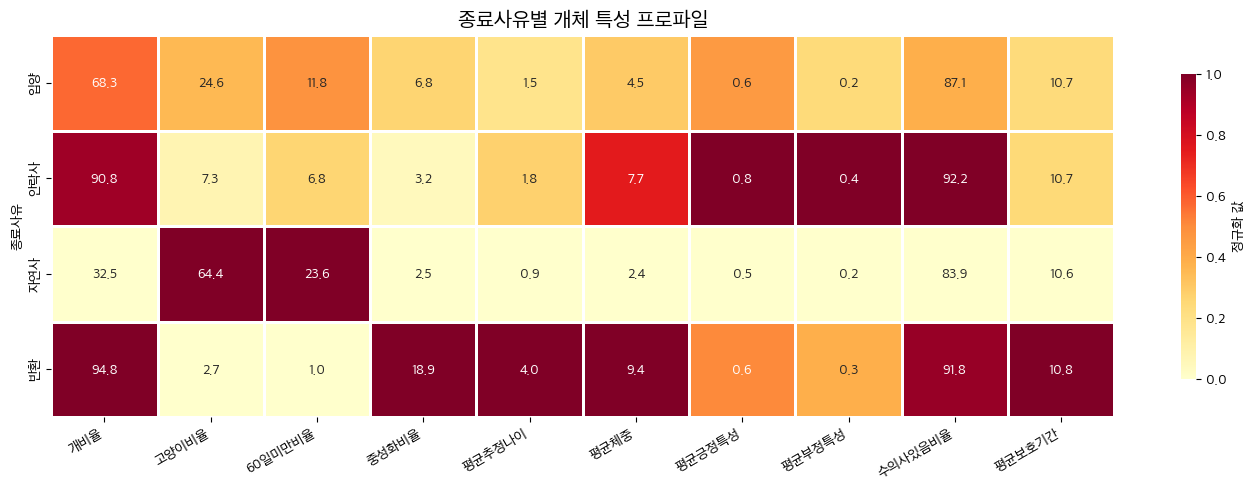

저장: individual_outcome_profile.png


In [4]:
# ── 셀 6: 종료사유별 개체 특성 프로파일 히트맵 ──
profile_vars = {
    '개비율': lambda x: (x['동물종류'] == '개').mean() * 100,
    '고양이비율': lambda x: (x['동물종류'] == '고양이').mean() * 100,
    '60일미만비율': lambda x: x['60일미만'].mean() * 100,
    '중성화비율': lambda x: (x['중성화 여부'] == '중성화 O').mean() * 100,
    '평균추정나이': lambda x: x['추정나이'].mean(),
    '평균체중': lambda x: x['체중_정제'].mean(),
    '평균긍정특성': lambda x: x['긍정특성수'].mean(),
    '평균부정특성': lambda x: x['부정특성수'].mean(),
    '수의사있음비율': lambda x: x['수의사유무'].mean() * 100,
    '평균보호기간': lambda x: x['duration'].mean(),
}

profile_data = {}
for outcome in target_cats:
    sub = df_main[df_main['종료사유_정제'] == outcome]
    profile_data[outcome] = {name: func(sub) for name, func in profile_vars.items()}

df_profile = pd.DataFrame(profile_data).T
# 정규화 (열 기준)
df_profile_norm = (df_profile - df_profile.min()) / (df_profile.max() - df_profile.min())

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_profile_norm, annot=df_profile.round(1).values, fmt='',
            cmap='YlOrRd', linewidths=1, linecolor='white',
            cbar_kws={'label': '정규화 값', 'shrink': 0.8}, ax=ax)
ax.set_title('종료사유별 개체 특성 프로파일', fontsize=15, fontweight='bold')
ax.set_ylabel('종료사유')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'individual_outcome_profile.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: individual_outcome_profile.png")


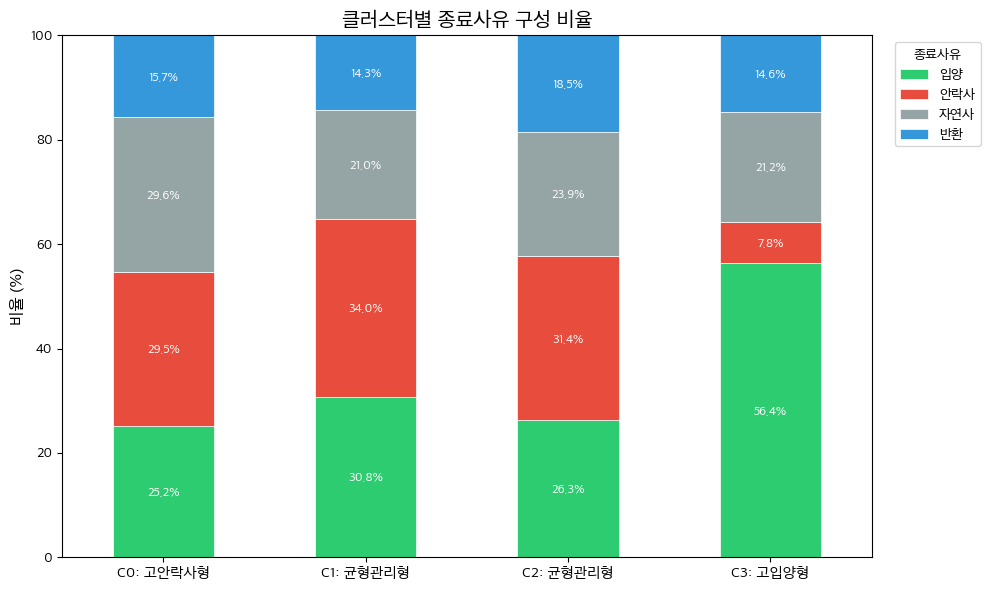

저장: cluster_outcome_mosaic.png


In [5]:
# ── 셀 7: 클러스터별 종료사유 비율 (100% 누적막대) ──
ct = pd.crosstab(df_main['cluster_v2'], df_main['종료사유_정제'], normalize='index') * 100
ct = ct[target_cats]  # 순서 통일

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#95a5a6', '#3498db']
ct.plot(kind='bar', stacked=True, color=colors, edgecolor='white', linewidth=0.5, ax=ax)

# 라벨 추가
for i, cluster in enumerate(ct.index):
    cumsum = 0
    for j, outcome in enumerate(target_cats):
        val = ct.loc[cluster, outcome]
        if val > 5:  # 5% 이상만 표시
            ax.text(i, cumsum + val/2, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        cumsum += val

# 클러스터 라벨 추가
cluster_labels = df_main.drop_duplicates('cluster_v2').set_index('cluster_v2')['cluster_v2_label'].to_dict()
ax.set_xticklabels([cluster_labels.get(c, f'C{c}') for c in ct.index], rotation=0, fontsize=11)

ax.set_ylabel('비율 (%)', fontsize=12)
ax.set_xlabel('')
ax.set_title('클러스터별 종료사유 구성 비율', fontsize=15, fontweight='bold')
ax.legend(title='종료사유', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 100)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cluster_outcome_mosaic.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: cluster_outcome_mosaic.png")


수의사 유무별 종료사유 비율 (개체 수준, N=2,817,413)
종료사유_정제     입양    안락사    자연사     반환
수의사유무                              
0        29.18  19.63  40.04  11.15
1        25.81  30.49  27.28  16.42

카이제곱 = 34252.8, df = 3, p < 0.001
Cramér's V = 0.1103

해석: V=0.1103는 중간 연관성
→ 79만건에서 통계적 유의성은 당연하므로, 효과크기(V) 중심 해석 필요


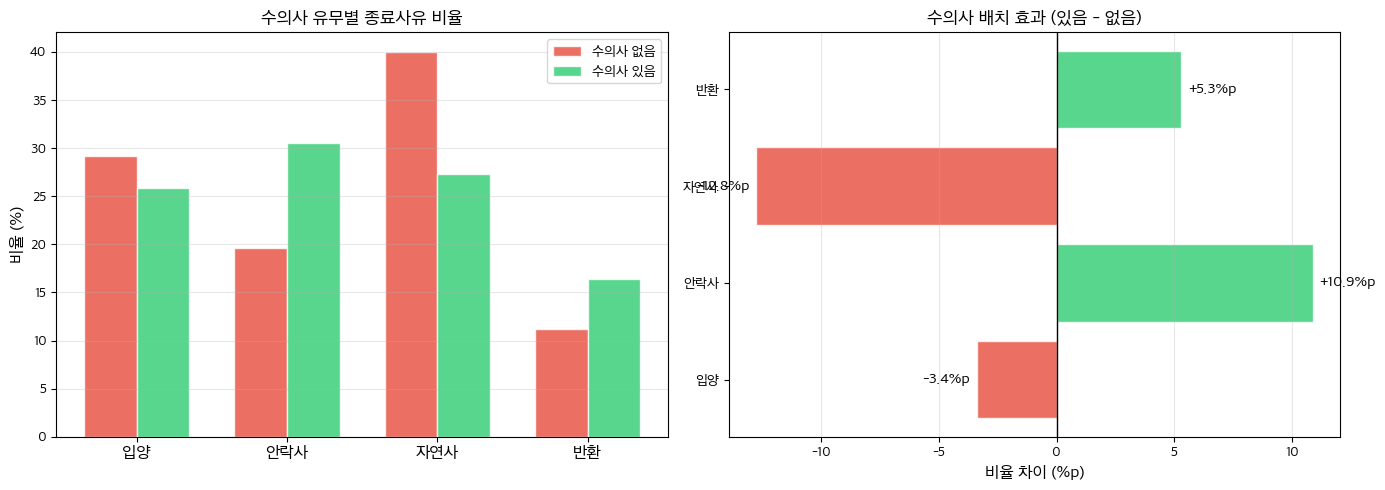

저장: vet_outcome_comparison.png


In [6]:
# ── 셀 8: 수의사 유무별 종료사유 비율 + 카이제곱 검정 (79만건 개체수준) ──
ct_vet = pd.crosstab(df_main['수의사유무'], df_main['종료사유_정제'])
ct_vet_pct = pd.crosstab(df_main['수의사유무'], df_main['종료사유_정제'], normalize='index') * 100
ct_vet_pct = ct_vet_pct[target_cats]

chi2, p_chi, dof, expected = stats.chi2_contingency(ct_vet)
n_total = ct_vet.sum().sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(ct_vet.shape) - 1)))

print("=" * 70)
print("수의사 유무별 종료사유 비율 (개체 수준, N={:,})".format(n_total))
print("=" * 70)
print(ct_vet_pct.round(2))
print(f"\n카이제곱 = {chi2:.1f}, df = {dof}, p < 0.001")
print(f"Cramér's V = {cramers_v:.4f}")
print(f"\n해석: V={cramers_v:.4f}는 {'약한' if cramers_v < 0.1 else '중간' if cramers_v < 0.3 else '강한'} 연관성")
print("→ 79만건에서 통계적 유의성은 당연하므로, 효과크기(V) 중심 해석 필요")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 비율 비교
x = np.arange(len(target_cats))
w = 0.35
for i, vet in enumerate([0, 1]):
    vals = ct_vet_pct.loc[vet, target_cats].values
    label = '수의사 없음' if vet == 0 else '수의사 있음'
    color = '#e74c3c' if vet == 0 else '#2ecc71'
    axes[0].bar(x + i*w - w/2, vals, w, label=label, color=color, alpha=0.8, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(target_cats, fontsize=12)
axes[0].set_ylabel('비율 (%)', fontsize=12)
axes[0].set_title('수의사 유무별 종료사유 비율', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 차이 (수의사있음 - 없음)
diff = ct_vet_pct.loc[1] - ct_vet_pct.loc[0]
diff = diff[target_cats]
colors_diff = ['#2ecc71' if v > 0 else '#e74c3c' for v in diff.values]
axes[1].barh(target_cats, diff.values, color=colors_diff, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('비율 차이 (%p)', fontsize=12)
axes[1].set_title('수의사 배치 효과 (있음 - 없음)', fontsize=13, fontweight='bold')
for i, (v, cat) in enumerate(zip(diff.values, target_cats)):
    axes[1].text(v + (0.3 if v > 0 else -0.3), i, f'{v:+.1f}%p',
                 va='center', ha='left' if v > 0 else 'right', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'vet_outcome_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: vet_outcome_comparison.png")


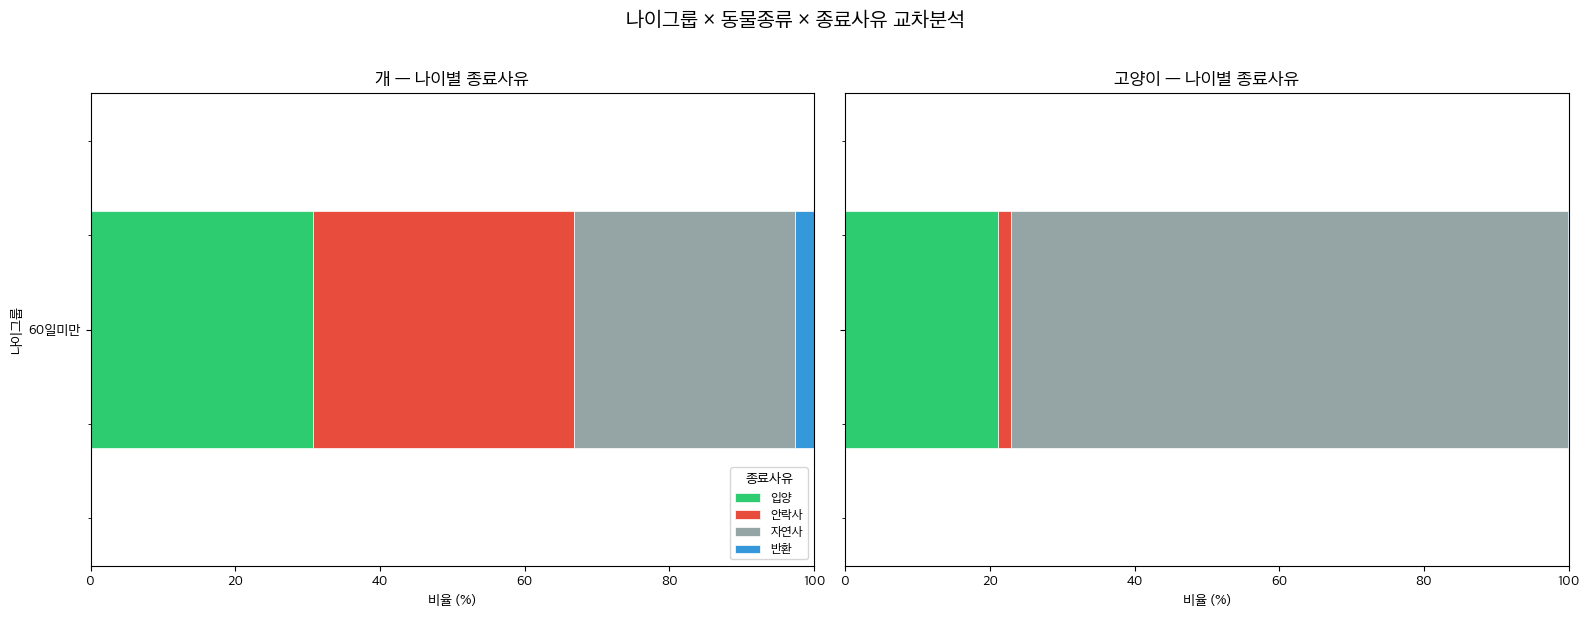

저장: age_species_outcome.png


In [7]:
# ── 셀 9: 나이그룹 x 동물종류 x 종료사유 3차원 교차분석 ──
animals = ['개', '고양이']
age_order = ['60일미만', '60일~1세', '1~2세', '2~3세', '3~5세', '5~7세', '7~10세', '10세이상']
# 실제 존재하는 나이그룹만 필터
age_order = [a for a in age_order if a in df_main['나이그룹'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for idx, animal in enumerate(animals):
    sub = df_main[df_main['동물종류'] == animal]
    ct_age = pd.crosstab(sub['나이그룹'], sub['종료사유_정제'], normalize='index') * 100
    ct_age = ct_age.reindex(index=[a for a in age_order if a in ct_age.index])
    ct_age = ct_age[[c for c in target_cats if c in ct_age.columns]]

    ct_age.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c', '#95a5a6', '#3498db'],
                edgecolor='white', linewidth=0.5, ax=axes[idx])
    axes[idx].set_title(f'{animal} — 나이별 종료사유', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('비율 (%)')
    axes[idx].set_xlim(0, 100)
    if idx == 0:
        axes[idx].legend(title='종료사유', loc='lower right', fontsize=9)
    else:
        axes[idx].get_legend().remove()

plt.suptitle('나이그룹 × 동물종류 × 종료사유 교차분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'age_species_outcome.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: age_species_outcome.png")


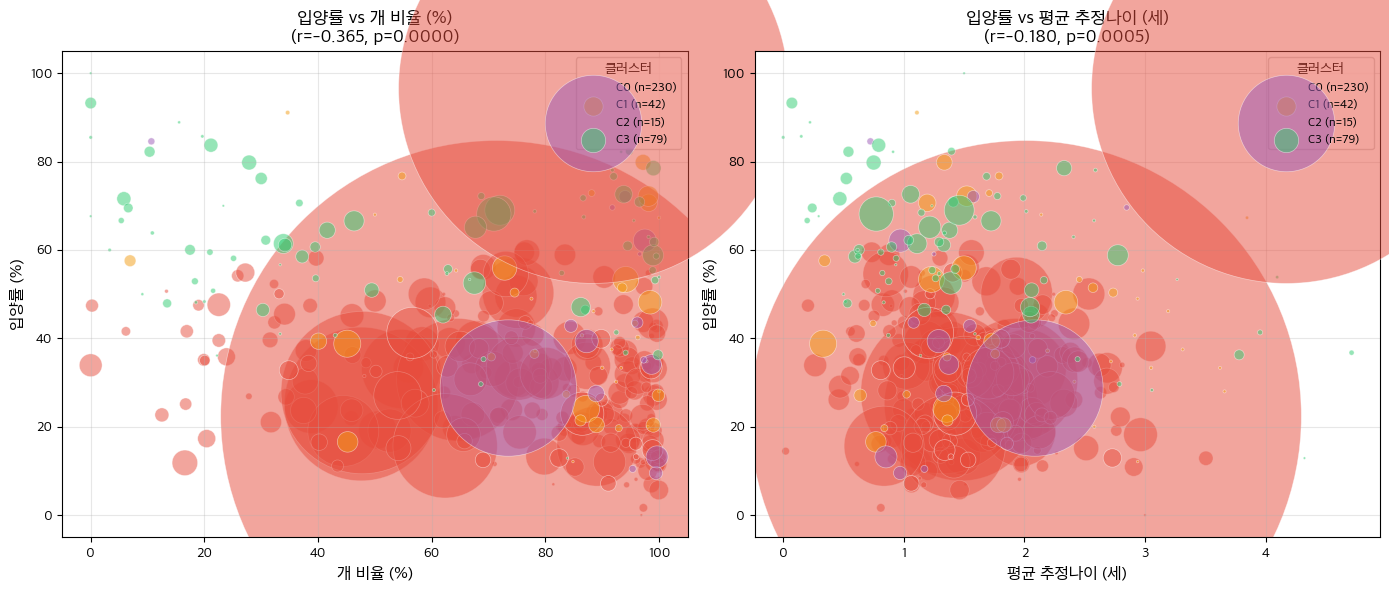

저장: shelter_adoption_composition.png


In [8]:
# ── 셀 10: 보호소별 입양률 vs 개체 구성 산점도 ──
shelter_stats = df_main.groupby('보호소명').agg(
    입양률=('입양여부', 'mean'),
    개비율=('동물종류', lambda x: (x == '개').mean()),
    평균나이=('추정나이', 'mean'),
    건수=('종료사유_정제', 'count'),
    cluster_v2=('cluster_v2', 'first'),
    수의사유무=('수의사유무', 'first'),
).reset_index()
shelter_stats['입양률'] *= 100
shelter_stats['개비율'] *= 100
shelter_stats = shelter_stats[shelter_stats['건수'] >= 30]  # 30건 이상

cluster_colors = {0: '#e74c3c', 1: '#f39c12', 2: '#9b59b6', 3: '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, xvar, xlabel in zip(axes, ['개비율', '평균나이'],
                              ['개 비율 (%)', '평균 추정나이 (세)']):
    for c in sorted(shelter_stats['cluster_v2'].unique()):
        sub = shelter_stats[shelter_stats['cluster_v2'] == c]
        label = f'C{c} (n={len(sub)})'
        ax.scatter(sub[xvar], sub['입양률'], c=cluster_colors.get(c, 'gray'),
                   alpha=0.5, s=sub['건수']/10, label=label, edgecolors='white', linewidth=0.5)
    r, p = stats.pearsonr(shelter_stats[xvar].dropna(),
                           shelter_stats.loc[shelter_stats[xvar].notna(), '입양률'])
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('입양률 (%)', fontsize=12)
    ax.set_title(f'입양률 vs {xlabel}\n(r={r:.3f}, p={p:.4f})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, title='클러스터')
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'shelter_adoption_composition.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: shelter_adoption_composition.png")


## Part 3. 다항 로지스틱 회귀 (Multinomial Logistic Regression)

### 핵심 질문
> "어떤 개체 특성과 보호소 특성이 입양/안락사/자연사/반환 **결과에 도달하는 확률**을 결정하는가?"

- **기준범주**: 입양 (base outcome)
- **비교범주**: 안락사, 자연사, 반환
- **해석**: RRR (Relative Risk Ratio) = exp(β) — 해당 변수 1단위 증가 시 입양 대비 해당 결과의 상대위험 변화
- **데이터**: 79만건 → 10% 층화 샘플 (~79,000건)로 MNLogit 적합, 전체 데이터 sklearn으로 검증

### 실질적 유의성 기준
79만건 대규모 데이터에서는 거의 모든 효과가 통계적으로 유의 → **RRR 중심 해석**
- RRR > 1.2 또는 < 0.8: "의미 있는 차이"
- RRR 1.0 근처: 통계적 유의해도 실질적 무의미


In [9]:
# ── 셀 12: 변수 인코딩 ──
# 범주형 더미화
df_model = df_main.copy()

# 동물종류 더미 (기준: 개)
df_model['is_고양이'] = (df_model['동물종류'] == '고양이').astype(int)
df_model['is_기타동물'] = (~df_model['동물종류'].isin(['개', '고양이'])).astype(int)

# 나이그룹 순서형 인코딩
age_map = {'60일미만': 0, '60일~1세': 1, '1~2세': 2, '2~3세': 3,
           '3~5세': 4, '5~7세': 5, '7~10세': 6, '10세이상': 7}
df_model['나이순서'] = df_model['나이그룹'].map(age_map).fillna(3)

# 성별 더미 (기준: 수컷)
df_model['is_암컷'] = (df_model['성별'] == '암컷').astype(int)
df_model['is_성별미상'] = (df_model['성별'] == '미상').astype(int)

# 중성화 더미 (기준: 미상)
df_model['is_중성화'] = (df_model['중성화 여부'] == '중성화 O').astype(int)
df_model['is_미중성화'] = (df_model['중성화 여부'] == '중성화 X').astype(int)

# 체중그룹 순서형
weight_map = {'2kg 이하': 0, '2~5kg': 1, '5~10kg': 2, '10~20kg': 3,
              '20~30kg': 4, '30kg 이상': 5}
df_model['체중순서'] = df_model['체중그룹'].map(weight_map).fillna(2)

# 독립변수 리스트
feature_cols = ['is_고양이', 'is_기타동물', '나이순서', 'is_암컷', 'is_성별미상',
                'is_중성화', 'is_미중성화', '체중순서', '긍정특성수', '부정특성수',
                '수의사유무', 'log_총인력']

# 결측 처리
for col in feature_cols:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# 종속변수 인코딩 (입양=0 기준)
outcome_map = {'입양': 0, '안락사': 1, '자연사': 2, '반환': 3}
df_model['outcome_code'] = df_model['종료사유_정제'].map(outcome_map)

print(f"모델링 데이터: {len(df_model):,}행, 독립변수 {len(feature_cols)}개")
print(f"종속변수 분포:")
print(df_model['outcome_code'].value_counts().sort_index().rename(
    {0: '입양(기준)', 1: '안락사', 2: '자연사', 3: '반환'}))


모델링 데이터: 2,817,413행, 독립변수 12개
종속변수 분포:
outcome_code
입양(기준)    738060
안락사       823724
자연사       810290
반환        445339
Name: count, dtype: int64


In [10]:
# ── 셀 13: 10% 층화 샘플링 + MNLogit 적합 ──
from sklearn.model_selection import StratifiedShuffleSplit

# 10% 층화 샘플
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
sample_idx, _ = next(sss.split(df_model[feature_cols], df_model['outcome_code']))
df_sample = df_model.iloc[sample_idx].reset_index(drop=True)
print(f"층화 샘플: {len(df_sample):,}행 (전체의 {len(df_sample)/len(df_model)*100:.1f}%)")
print(f"샘플 종속변수 분포:")
print(df_sample['종료사유_정제'].value_counts())

# MNLogit 적합
X_mnl = sm.add_constant(df_sample[feature_cols].astype(float))
y_mnl = df_sample['outcome_code']

print("\nMNLogit 적합 중... (약 1~3분 소요)")
mnl_model = MNLogit(y_mnl, X_mnl)
mnl_result = mnl_model.fit(method='bfgs', maxiter=500, disp=0)
print(f"수렴 여부: {mnl_result.mle_retvals['converged']}")
print(f"Log-Likelihood: {mnl_result.llf:.1f}")
print(f"Pseudo R²: {mnl_result.prsquared:.4f}")
print(f"AIC: {mnl_result.aic:.1f}")


층화 샘플: 281,741행 (전체의 10.0%)
샘플 종속변수 분포:
종료사유_정제
안락사    82372
자연사    81029
입양     73806
반환     44534
Name: count, dtype: int64

MNLogit 적합 중... (약 1~3분 소요)


수렴 여부: True
Log-Likelihood: -313092.6


Pseudo R²: 0.1832
AIC: 626263.1


In [11]:
# ── 셀 14: RRR 테이블 생성 + 핵심 질문별 해석 ──
# RRR = exp(계수), CI from params ± 1.96*bse
params = mnl_result.params
bse = mnl_result.bse
pvalues = mnl_result.pvalues

# MNLogit params columns: [0, 1, 2] → 각각 안락사(1), 자연사(2), 반환(3) vs 입양(0)
outcome_labels = {0: '안락사 vs 입양', 1: '자연사 vs 입양', 2: '반환 vs 입양'}
rrr_rows = []

for outcome_idx, outcome_name in outcome_labels.items():
    for var in feature_cols:
        coef = params.loc[var, outcome_idx]
        se = bse.loc[var, outcome_idx]
        rrr = np.exp(coef)
        pval = pvalues.loc[var, outcome_idx]
        ci_lo = np.exp(coef - 1.96 * se)
        ci_hi = np.exp(coef + 1.96 * se)

        # 실질적 유의성
        practical = 'O' if (rrr > 1.2 or rrr < 0.8) and pval < 0.05 else '-'

        rrr_rows.append({
            '비교': outcome_name,
            '변수': var,
            'RRR': round(rrr, 4),
            '95%CI_하': round(ci_lo, 4),
            '95%CI_상': round(ci_hi, 4),
            'p값': round(pval, 4),
            '실질적유의': practical
        })

df_rrr = pd.DataFrame(rrr_rows)

# 핵심 변수별 해석
print("=" * 80)
print("MNLogit RRR 결과 — 핵심 질문별 해석")
print("=" * 80)

key_vars = ['수의사유무', '나이순서', 'is_고양이', '긍정특성수', '부정특성수']
for var in key_vars:
    print(f"\n▶ {var}")
    sub = df_rrr[df_rrr['변수'] == var]
    for _, row in sub.iterrows():
        sig = '***' if row['p값'] < 0.001 else ('**' if row['p값'] < 0.01 else ('*' if row['p값'] < 0.05 else 'ns'))
        print(f"  {row['비교']}: RRR={row['RRR']:.3f} "
              f"[{row['95%CI_하']:.3f}, {row['95%CI_상']:.3f}] {sig} {row['실질적유의']}")

# CSV 저장
rrr_path = os.path.join(DATA_DIR, 'individual_mnlogit_results.csv')
df_rrr.to_csv(rrr_path, index=False, encoding='utf-8-sig')
print(f"\nRRR 결과 저장: {rrr_path}")


MNLogit RRR 결과 — 핵심 질문별 해석

▶ 수의사유무
  안락사 vs 입양: RRR=0.715 [0.681, 0.750] *** O
  자연사 vs 입양: RRR=0.624 [0.597, 0.653] *** O
  반환 vs 입양: RRR=0.854 [0.805, 0.905] *** -

▶ 나이순서
  안락사 vs 입양: RRR=1.046 [1.032, 1.060] *** -
  자연사 vs 입양: RRR=0.871 [0.861, 0.880] *** -
  반환 vs 입양: RRR=1.587 [1.535, 1.642] *** O

▶ is_고양이
  안락사 vs 입양: RRR=0.336 [0.324, 0.347] *** O
  자연사 vs 입양: RRR=4.747 [4.622, 4.876] *** O
  반환 vs 입양: RRR=0.151 [0.142, 0.161] *** O

▶ 긍정특성수
  안락사 vs 입양: RRR=1.147 [1.133, 1.162] *** -
  자연사 vs 입양: RRR=0.897 [0.884, 0.911] *** -
  반환 vs 입양: RRR=0.937 [0.922, 0.952] *** -

▶ 부정특성수
  안락사 vs 입양: RRR=1.355 [1.327, 1.383] *** O
  자연사 vs 입양: RRR=0.981 [0.958, 1.005] ns -
  반환 vs 입양: RRR=0.836 [0.815, 0.858] *** -

RRR 결과 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/individual_mnlogit_results.csv


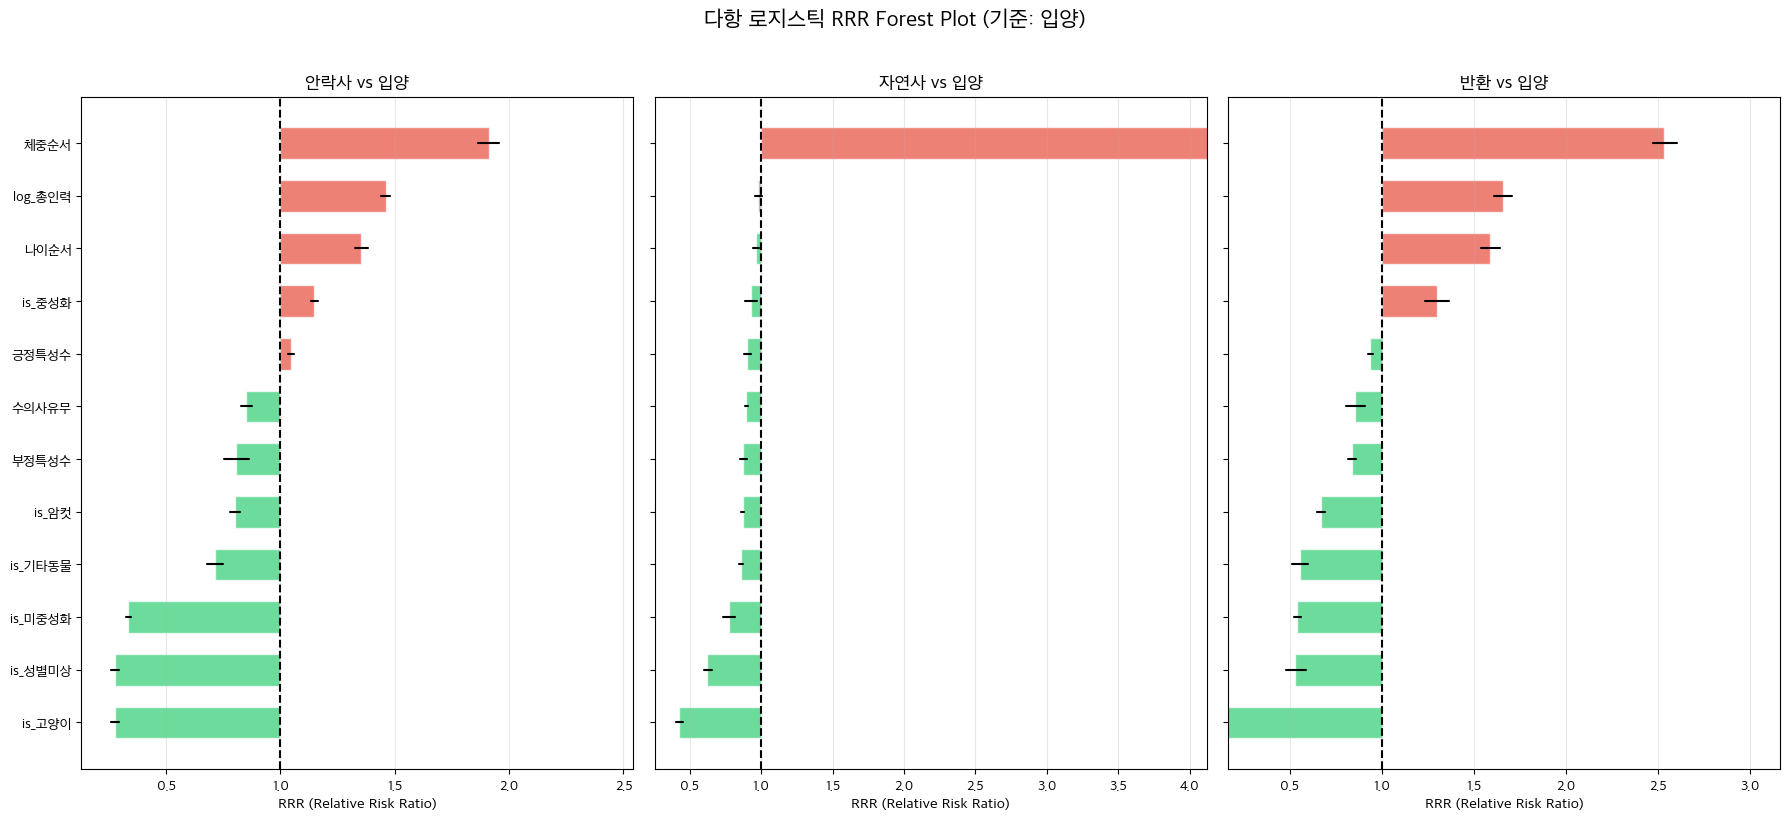

저장: mnlogit_rrr_forest.png


In [12]:
# ── 셀 15: RRR Forest Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

for ax_idx, (outcome_idx, outcome_name) in enumerate(outcome_labels.items()):
    sub = df_rrr[df_rrr['비교'] == outcome_name].copy()
    sub = sub.sort_values('RRR', ascending=True)

    y_pos = np.arange(len(sub))
    colors = []
    for _, row in sub.iterrows():
        if row['p값'] >= 0.05:
            colors.append('#999999')
        elif row['RRR'] > 1:
            colors.append('#e74c3c')
        else:
            colors.append('#2ecc71')

    axes[ax_idx].barh(y_pos, sub['RRR'].values - 1, left=1, color=colors,
                       alpha=0.7, edgecolor='white', height=0.6)

    # 오류 막대
    for i, (_, row) in enumerate(sub.iterrows()):
        axes[ax_idx].plot([row['95%CI_하'], row['95%CI_상']], [i, i],
                          color='black', linewidth=1.5, solid_capstyle='round')

    axes[ax_idx].axvline(1, color='black', linewidth=1.5, linestyle='--')
    axes[ax_idx].set_yticks(y_pos)
    axes[ax_idx].set_yticklabels(sub['변수'].values, fontsize=10)
    axes[ax_idx].set_xlabel('RRR (Relative Risk Ratio)', fontsize=11)
    axes[ax_idx].set_title(outcome_name, fontsize=13, fontweight='bold')
    axes[ax_idx].grid(axis='x', alpha=0.3)

    # x축 범위 제한 (극단값 방지)
    ci_max = sub['95%CI_상'].quantile(0.95)
    ci_min = sub['95%CI_하'].quantile(0.05)
    axes[ax_idx].set_xlim(max(0.01, ci_min * 0.5), min(ci_max * 1.5, 10))

plt.suptitle('다항 로지스틱 RRR Forest Plot (기준: 입양)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mnlogit_rrr_forest.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: mnlogit_rrr_forest.png")


In [13]:
# ── 셀 16: 전체 79만건 이항 로지스틱(입양 vs 비입양, sklearn)으로 방향성 검증 ──
from sklearn.model_selection import train_test_split

X_full = df_model[feature_cols].values
y_full = df_model['입양여부'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_sc, y_train)

y_pred_proba = lr.predict_proba(X_test_sc)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"이항 로지스틱 (입양 vs 비입양) — 전체 {len(df_model):,}건")
print(f"  AUC: {auc:.4f}")

# 계수 비교
coef_df = pd.DataFrame({
    '변수': feature_cols,
    '표준화계수': lr.coef_[0],
    '방향': ['입양↑' if c > 0 else '입양↓' for c in lr.coef_[0]]
}).sort_values('표준화계수', key=abs, ascending=False)

print(f"\n변수별 표준화 계수 (입양 확률 기여):")
for _, row in coef_df.iterrows():
    bar = '█' * int(abs(row['표준화계수']) * 10)
    sign = '+' if row['표준화계수'] > 0 else '-'
    print(f"  {row['변수']:<15} {sign}{abs(row['표준화계수']):.4f}  {bar}  {row['방향']}")

# MNLogit과 방향성 비교
print(f"\n=== MNLogit vs sklearn 방향성 비교 ===")
for var in key_vars:
    mnl_rrr = df_rrr[(df_rrr['변수'] == var) & (df_rrr['비교'] == '안락사 vs 입양')]['RRR'].values
    sk_coef = coef_df[coef_df['변수'] == var]['표준화계수'].values
    if len(mnl_rrr) > 0 and len(sk_coef) > 0:
        mnl_dir = '안락사↑' if mnl_rrr[0] > 1 else '입양↑'
        sk_dir = '입양↑' if sk_coef[0] > 0 else '입양↓'
        consistent = '일치' if (mnl_dir == '입양↑') == (sk_dir == '입양↑') or \
                              (mnl_dir == '안락사↑') == (sk_dir == '입양↓') else '불일치'
        print(f"  {var}: MNLogit RRR={mnl_rrr[0]:.3f}({mnl_dir}), sklearn={sk_coef[0]:.4f}({sk_dir}) → {consistent}")


이항 로지스틱 (입양 vs 비입양) — 전체 2,817,413건
  AUC: 0.5937

변수별 표준화 계수 (입양 확률 기여):
  체중순서            -0.2169  ██  입양↓
  log_총인력         -0.1959  █  입양↓
  is_고양이          -0.1877  █  입양↓
  is_기타동물         +0.1771  █  입양↑
  is_미중성화         +0.1012  █  입양↑
  is_중성화          +0.1012  █  입양↑
  수의사유무           +0.0997    입양↑
  is_암컷           +0.0846    입양↑
  부정특성수           -0.0610    입양↓
  나이순서            +0.0535    입양↑
  긍정특성수           +0.0105    입양↑
  is_성별미상         -0.0079    입양↓

=== MNLogit vs sklearn 방향성 비교 ===
  수의사유무: MNLogit RRR=0.715(입양↑), sklearn=0.0997(입양↑) → 일치
  나이순서: MNLogit RRR=1.046(안락사↑), sklearn=0.0535(입양↑) → 불일치
  is_고양이: MNLogit RRR=0.336(입양↑), sklearn=-0.1877(입양↓) → 불일치
  긍정특성수: MNLogit RRR=1.147(안락사↑), sklearn=0.0105(입양↑) → 불일치
  부정특성수: MNLogit RRR=1.355(안락사↑), sklearn=-0.0610(입양↓) → 일치


## Part 4. 경쟁적 위험 분석 (Competing Risks)

### 배경
보호기간일 중앙값=10일, P75=11일로 매우 집중 (법정 공고기간 10일 영향).
전통적 생존분석의 시간축 변별력이 낮지만, **CIF(Cumulative Incidence Function)**로 "최종 어떤 결과에 도달하는가"를 비교 가능.

- **이벤트 인코딩**: 입양=1, 안락사=2, 자연사=3, 반환=4
- **AalenJohansenFitter**: 경쟁적 위험 하에서 이벤트별 누적 발생률 추정


In [14]:
# ── 셀 18: 이벤트 인코딩 ──
event_map = {'입양': 1, '안락사': 2, '자연사': 3, '반환': 4}
df_surv = df_main[['duration', '종료사유_정제', '동물종류', '나이그룹',
                    '수의사유무', 'cluster_v2', 'cluster_v2_label']].copy()
df_surv['event'] = df_surv['종료사유_정제'].map(event_map)
df_surv['observed'] = 1  # 모두 이벤트 관측됨 (censored 없음)

print(f"생존분석 데이터: {len(df_surv):,}행")
print(f"\n이벤트 분포:")
print(df_surv['event'].value_counts().sort_index().rename(
    {1: '입양', 2: '안락사', 3: '자연사', 4: '반환'}))
print(f"\nduration 통계:")
print(df_surv['duration'].describe().round(2))


생존분석 데이터: 2,817,413행

이벤트 분포:
event
입양     738060
안락사    823724
자연사    810290
반환     445339
Name: count, dtype: int64

duration 통계:
count    2817413.00
mean          10.68
std            2.21
min            0.50
25%           10.00
50%           10.00
75%           11.00
max          180.00
Name: duration, dtype: float64


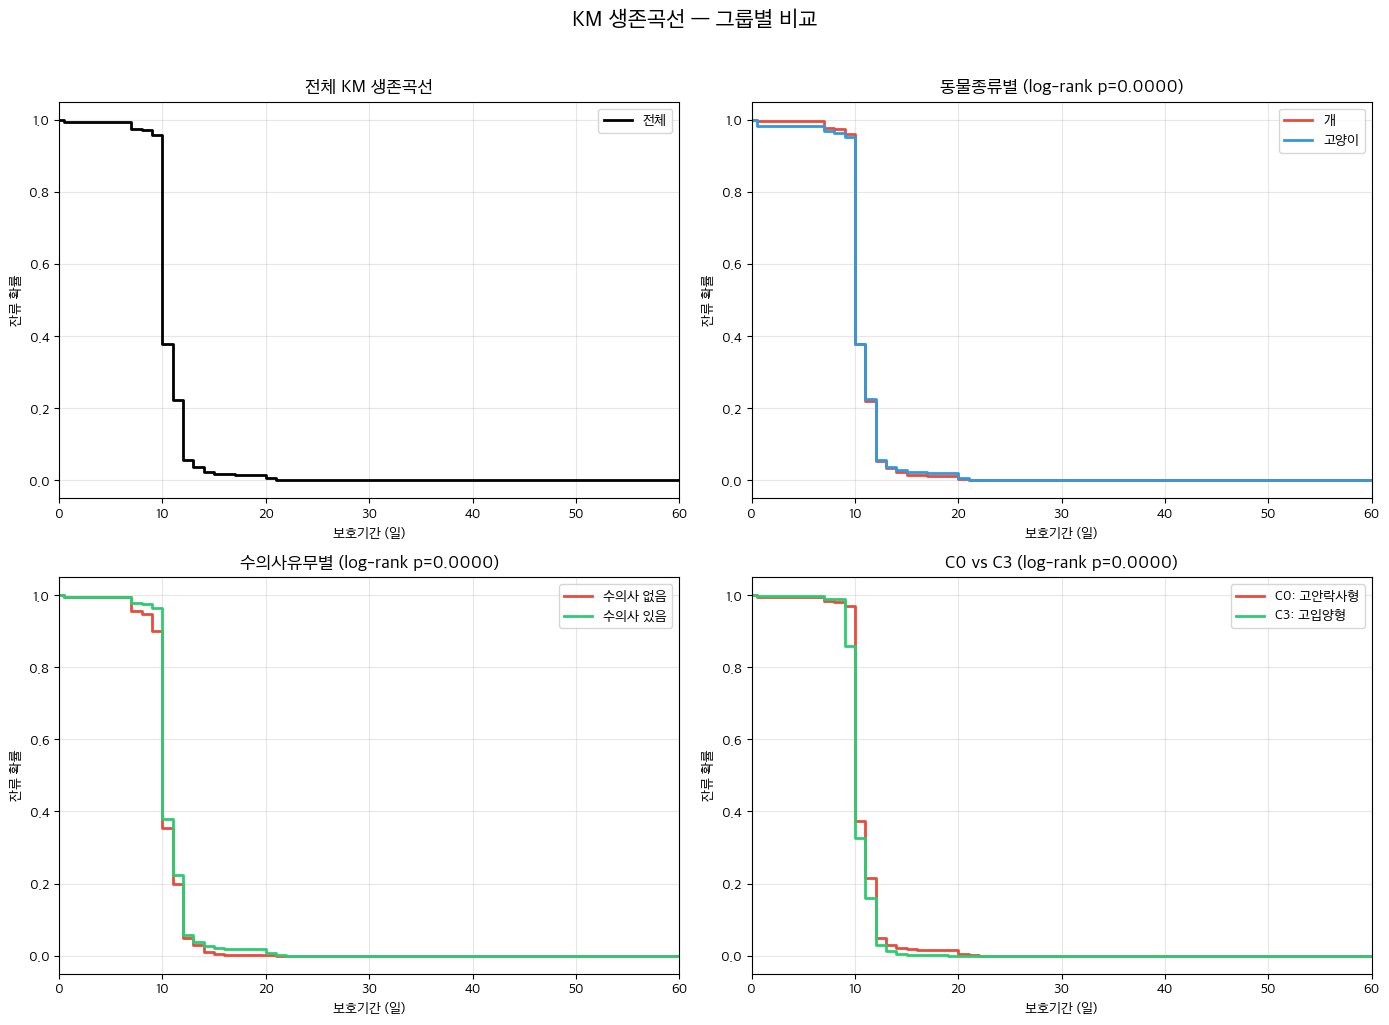

저장: km_curves_by_group.png


In [15]:
# ── 셀 19: KM 전체 + 그룹별 + Log-rank 검정 ──

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 전체 KM
kmf = KaplanMeierFitter()
kmf.fit(df_surv['duration'], event_observed=df_surv['observed'], label='전체')
kmf.plot_survival_function(ax=axes[0, 0], ci_show=False, color='black', linewidth=2)
axes[0, 0].set_title('전체 KM 생존곡선', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('보호기간 (일)')
axes[0, 0].set_ylabel('잔류 확률')
axes[0, 0].set_xlim(0, 60)

# (2) 동물종류별
colors_sp = {'개': '#e74c3c', '고양이': '#3498db'}
for sp in ['개', '고양이']:
    sub = df_surv[df_surv['동물종류'] == sp]
    kmf_sp = KaplanMeierFitter()
    kmf_sp.fit(sub['duration'], event_observed=sub['observed'], label=sp)
    kmf_sp.plot_survival_function(ax=axes[0, 1], ci_show=False,
                                   color=colors_sp.get(sp, 'gray'), linewidth=2)
dog = df_surv[df_surv['동물종류'] == '개']
cat = df_surv[df_surv['동물종류'] == '고양이']
lr_sp = logrank_test(dog['duration'], cat['duration'],
                      event_observed_A=dog['observed'], event_observed_B=cat['observed'])
axes[0, 1].set_title(f'동물종류별 (log-rank p={lr_sp.p_value:.4f})', fontsize=13, fontweight='bold')
axes[0, 1].set_xlim(0, 60)

# (3) 수의사유무별
colors_vet = {0: '#e74c3c', 1: '#2ecc71'}
for vet in [0, 1]:
    sub = df_surv[df_surv['수의사유무'] == vet]
    label = '수의사 없음' if vet == 0 else '수의사 있음'
    kmf_v = KaplanMeierFitter()
    kmf_v.fit(sub['duration'], event_observed=sub['observed'], label=label)
    kmf_v.plot_survival_function(ax=axes[1, 0], ci_show=False,
                                  color=colors_vet[vet], linewidth=2)
v0 = df_surv[df_surv['수의사유무'] == 0]
v1 = df_surv[df_surv['수의사유무'] == 1]
lr_vet = logrank_test(v0['duration'], v1['duration'],
                       event_observed_A=v0['observed'], event_observed_B=v1['observed'])
axes[1, 0].set_title(f'수의사유무별 (log-rank p={lr_vet.p_value:.4f})', fontsize=13, fontweight='bold')
axes[1, 0].set_xlim(0, 60)

# (4) 클러스터별 (C0 vs C3)
colors_cl = {0: '#e74c3c', 3: '#2ecc71'}
for c in [0, 3]:
    sub = df_surv[df_surv['cluster_v2'] == c]
    label = sub['cluster_v2_label'].iloc[0] if len(sub) > 0 else f'C{c}'
    kmf_c = KaplanMeierFitter()
    kmf_c.fit(sub['duration'], event_observed=sub['observed'], label=label)
    kmf_c.plot_survival_function(ax=axes[1, 1], ci_show=False,
                                  color=colors_cl[c], linewidth=2)
c0 = df_surv[df_surv['cluster_v2'] == 0]
c3 = df_surv[df_surv['cluster_v2'] == 3]
lr_cl = logrank_test(c0['duration'], c3['duration'],
                      event_observed_A=c0['observed'], event_observed_B=c3['observed'])
axes[1, 1].set_title(f'C0 vs C3 (log-rank p={lr_cl.p_value:.4f})', fontsize=13, fontweight='bold')
axes[1, 1].set_xlim(0, 60)

for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.set_xlabel('보호기간 (일)')
    ax.set_ylabel('잔류 확률')

plt.suptitle('KM 생존곡선 — 그룹별 비교', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'km_curves_by_group.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: km_curves_by_group.png")


AJ 분석 표본: 50,000행


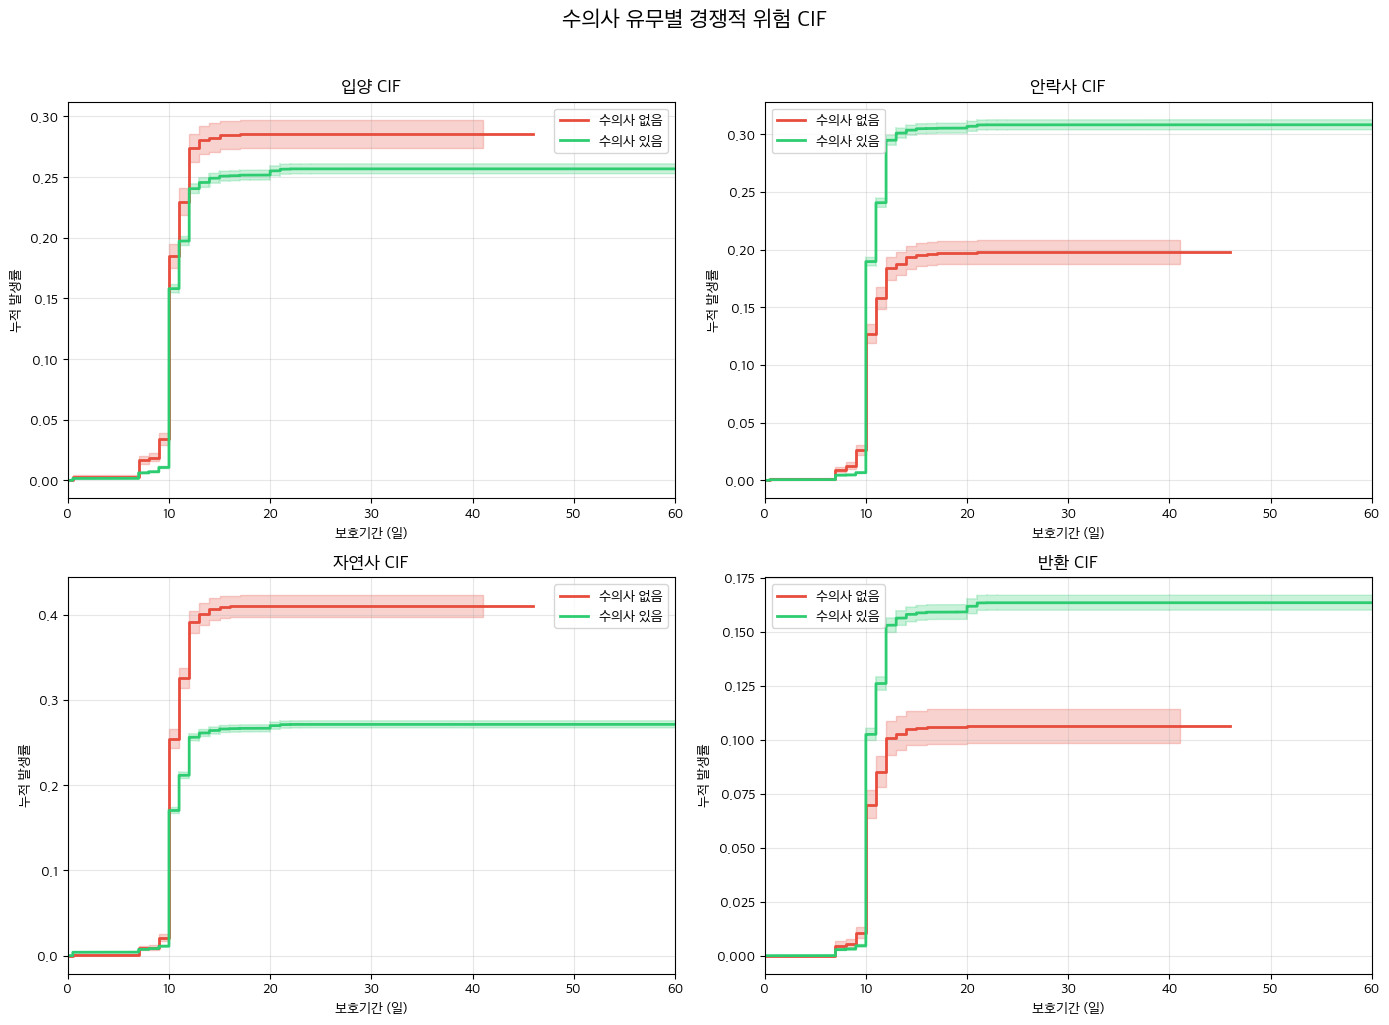

저장: cif_vet_comparison.png


In [16]:
# ── 셀 20: AalenJohansenFitter — 수의사유무별 CIF 비교 ──

# 샘플링 (AJ는 대규모 데이터에서 느림)
n_aj_sample = 50000
if len(df_surv) > n_aj_sample:
    rng = np.random.default_rng(42)
    aj_idx = rng.choice(len(df_surv), n_aj_sample, replace=False)
    df_aj = df_surv.iloc[aj_idx].reset_index(drop=True)
else:
    df_aj = df_surv.copy()
print(f"AJ 분석 표본: {len(df_aj):,}행")

event_names = {1: '입양', 2: '안락사', 3: '자연사', 4: '반환'}
vet_labels = {0: '수의사 없음', 1: '수의사 있음'}
vet_colors = {0: '#e74c3c', 1: '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for ev_idx, (event_code, event_name) in enumerate(event_names.items()):
    ax = axes_flat[ev_idx]
    for vet in [0, 1]:
        sub = df_aj[df_aj['수의사유무'] == vet]
        ajf = AalenJohansenFitter()
        ajf.fit(sub['duration'], sub['event'], event_of_interest=event_code)
        ajf.plot(ax=ax, label=vet_labels[vet], color=vet_colors[vet], linewidth=2)

    ax.set_title(f'{event_name} CIF', fontsize=13, fontweight='bold')
    ax.set_xlabel('보호기간 (일)')
    ax.set_ylabel('누적 발생률')
    ax.set_xlim(0, 60)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('수의사 유무별 경쟁적 위험 CIF', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cif_vet_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: cif_vet_comparison.png")


C0 vs C3 분석 표본: 45,148행


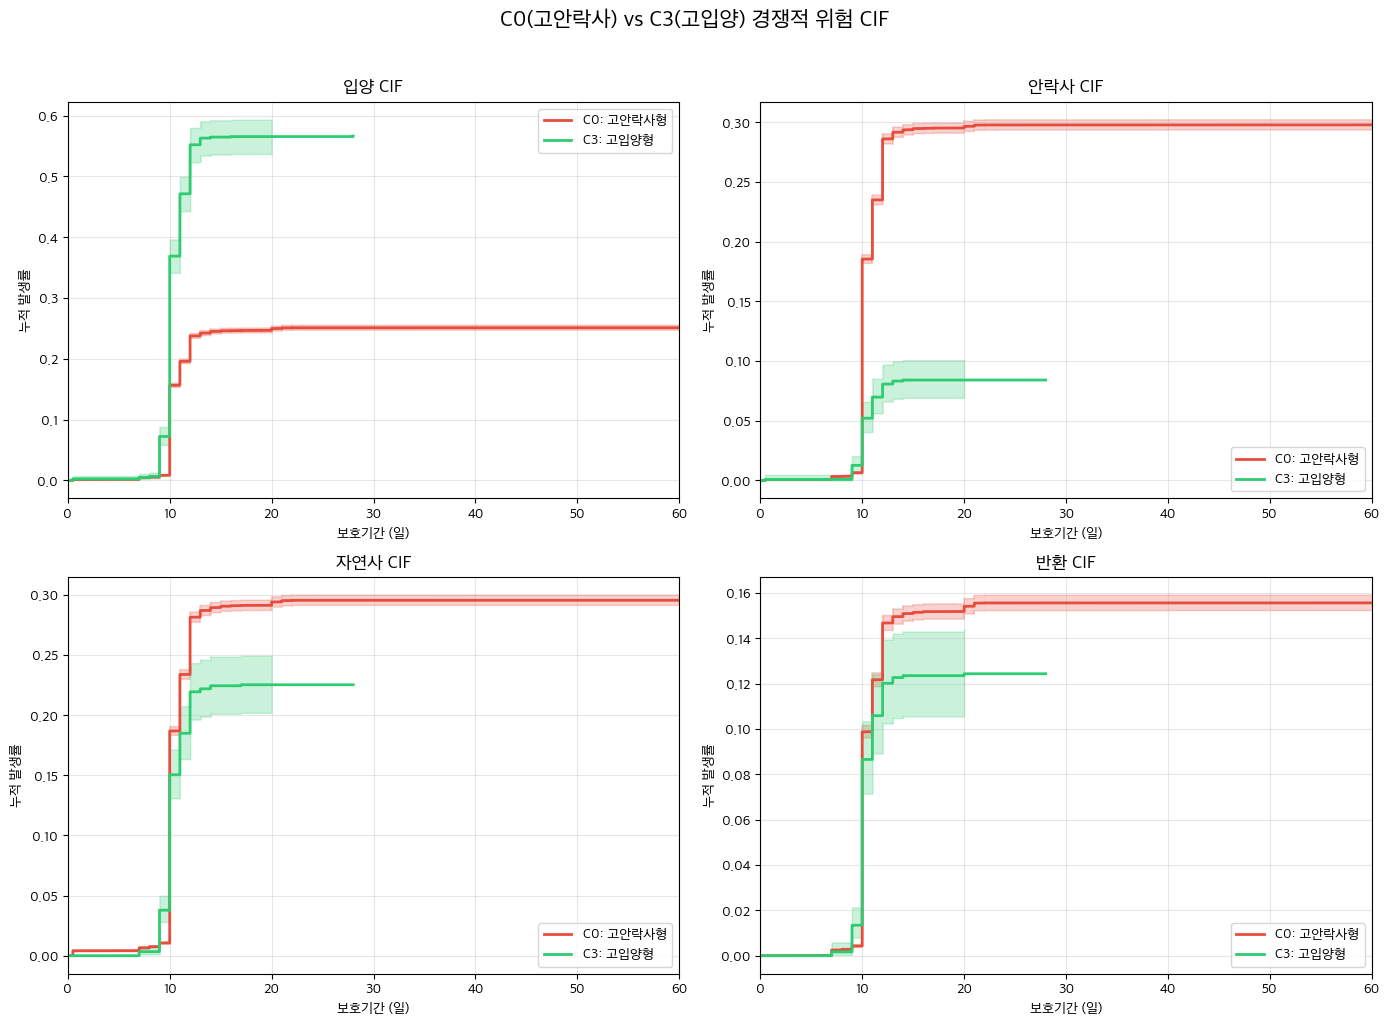

저장: cif_cluster_comparison.png


In [17]:
# ── 셀 21: 클러스터별 CIF 비교 (C0 vs C3) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

cluster_labels_map = {0: 'C0: 고안락사형', 3: 'C3: 고입양형'}
cluster_colors_map = {0: '#e74c3c', 3: '#2ecc71'}

df_aj_cl = df_aj[df_aj['cluster_v2'].isin([0, 3])].reset_index(drop=True)
print(f"C0 vs C3 분석 표본: {len(df_aj_cl):,}행")

for ev_idx, (event_code, event_name) in enumerate(event_names.items()):
    ax = axes_flat[ev_idx]
    for cl in [0, 3]:
        sub = df_aj_cl[df_aj_cl['cluster_v2'] == cl]
        if len(sub) < 10:
            continue
        ajf = AalenJohansenFitter()
        ajf.fit(sub['duration'], sub['event'], event_of_interest=event_code)
        ajf.plot(ax=ax, label=cluster_labels_map.get(cl, f'C{cl}'),
                 color=cluster_colors_map.get(cl, 'gray'), linewidth=2)

    ax.set_title(f'{event_name} CIF', fontsize=13, fontweight='bold')
    ax.set_xlabel('보호기간 (일)')
    ax.set_ylabel('누적 발생률')
    ax.set_xlim(0, 60)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('C0(고안락사) vs C3(고입양) 경쟁적 위험 CIF', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cif_cluster_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: cif_cluster_comparison.png")


In [18]:
# ── 셀 22: CIF 차이 정량화 테이블 ──
timepoints = [10, 15, 30]  # 보호기간 10일, 15일, 30일 시점

cif_rows = []
for group_var, group_vals, group_labels in [
    ('수의사유무', [0, 1], {0: '수의사없음', 1: '수의사있음'}),
    ('cluster_v2', [0, 3], {0: 'C0(고안락사)', 3: 'C3(고입양)'})
]:
    for event_code, event_name in event_names.items():
        for t in timepoints:
            vals = {}
            for gv in group_vals:
                sub = df_aj[df_aj[group_var] == gv] if group_var == '수의사유무' else \
                      df_aj_cl[df_aj_cl[group_var] == gv]
                if len(sub) < 10:
                    vals[gv] = np.nan
                    continue
                ajf = AalenJohansenFitter()
                ajf.fit(sub['duration'], sub['event'], event_of_interest=event_code)
                ci = ajf.cumulative_density_
                # 가장 가까운 시점의 CIF 값
                valid_times = ci.index[ci.index <= t]
                if len(valid_times) > 0:
                    vals[gv] = ci.loc[valid_times[-1]].values[0]
                else:
                    vals[gv] = 0.0

            if len(vals) == 2:
                v0, v1 = vals[group_vals[0]], vals[group_vals[1]]
                cif_rows.append({
                    '비교': f"{group_labels[group_vals[0]]} vs {group_labels[group_vals[1]]}",
                    '이벤트': event_name,
                    '시점(일)': t,
                    f'{group_labels[group_vals[0]]}': round(v0, 4),
                    f'{group_labels[group_vals[1]]}': round(v1, 4),
                    '차이': round(v1 - v0, 4)
                })

df_cif_summary = pd.DataFrame(cif_rows)
print("=" * 80)
print("CIF 정량 비교 (보호기간 시점별)")
print("=" * 80)
display(df_cif_summary)


CIF 정량 비교 (보호기간 시점별)


,비교,이벤트,시점(일),수의사없음,수의사있음,차이,C0(고안락사),C3(고입양)
0,수의사없음 vs 수의사있음,입양,10,0.1849,0.0845,-0.1004,NaN,NaN
1,수의사없음 vs 수의사있음,입양,15,0.2843,0.2499,-0.0344,NaN,NaN
2,수의사없음 vs 수의사있음,입양,30,0.2854,0.2568,-0.0286,NaN,NaN
3,수의사없음 vs 수의사있음,안락사,10,0.1271,0.0995,-0.0277,NaN,NaN
4,수의사없음 vs 수의사있음,안락사,15,0.1956,0.3042,0.1086,NaN,NaN
5,수의사없음 vs 수의사있음,안락사,30,0.1977,0.3082,0.1105,NaN,NaN
6,수의사없음 vs 수의사있음,자연사,10,0.2542,0.0908,-0.1634,NaN,NaN
7,수의사없음 vs 수의사있음,자연사,15,0.4090,0.2649,-0.1441,NaN,NaN
8,수의사없음 vs 수의사있음,자연사,30,0.4102,0.2713,-0.1389,NaN,NaN
9,수의사없음 vs 수의사있음,반환,10,0.0700,0.0538,-0.0162,NaN,NaN


## Part 5. Cox PH 모델

### 설계
- **입양 Cox PH**: 입양=event, 나머지=censored (strata=cluster_v2)
- **안락사 Cox PH**: 안락사=event, 나머지=censored
- **Robust SE**: 보호소 클러스터링에 의한 분산 보정
- **PH 가정**: Schoenfeld 잔차 검정

### 실질적 유의성 기준
- HR > 1.2 또는 < 0.8: "의미 있는 차이"
- 79만건에서 p-value는 거의 무의미 → HR과 CI 중심 해석


In [19]:
# ── 셀 24: 입양 Cox PH ──
# 입양=event(1), 나머지=censored(0)
df_cox = df_model[['duration', '종료사유_정제', 'cluster_v2'] + feature_cols].copy()
df_cox['event_adoption'] = (df_cox['종료사유_정제'] == '입양').astype(int)
df_cox['event_euthanasia'] = (df_cox['종료사유_정제'] == '안락사').astype(int)
df_cox['cluster_v2'] = df_cox['cluster_v2'].astype(str)  # strata용 문자열 변환

# 20% 샘플 (Cox PH는 대규모 데이터에서 느림)
n_cox_sample = min(150000, len(df_cox))
rng_cox = np.random.default_rng(42)
cox_idx = rng_cox.choice(len(df_cox), n_cox_sample, replace=False)
df_cox_sample = df_cox.iloc[cox_idx].reset_index(drop=True)
print(f"Cox PH 표본: {len(df_cox_sample):,}행")

# 입양 Cox PH (strata=cluster_v2)
cox_adoption = CoxPHFitter()
cox_vars = feature_cols.copy()
cox_fit_cols = ['duration', 'event_adoption', 'cluster_v2'] + cox_vars

print("\n입양 Cox PH 적합 중...")
cox_adoption.fit(
    df_cox_sample[cox_fit_cols],
    duration_col='duration',
    event_col='event_adoption',
    strata=['cluster_v2'],
    robust=True,
    show_progress=False
)

print(f"\n=== 입양 Cox PH 결과 ===")
print(f"Concordance: {cox_adoption.concordance_index_:.4f}")
print(f"Partial AIC: {cox_adoption.AIC_partial_:.1f}")
cox_adoption.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])


Cox PH 표본: 150,000행

입양 Cox PH 적합 중...



=== 입양 Cox PH 결과 ===


Concordance: 0.5756
Partial AIC: 833020.8


<lifelines.CoxPHFitter: fitted with 150000 total observations, 110563 right-censored observations>
             duration col = 'duration'
                event col = 'event_adoption'
          robust variance = True
                   strata = cluster_v2
      baseline estimation = breslow
   number of observations = 150000
number of events observed = 39437
   partial log-likelihood = -416498.38
         time fit was run = 2026-03-24 06:38:17 UTC

---
           coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                         
is_고양이    -0.34      0.71      0.02                0.69                0.73 <0.005
is_기타동물    0.58      1.79      0.03                1.69                1.88 <0.005
나이순서       0.03      1.03      0.01                1.02                1.04 <0.005
is_암컷      0.13      1.13      0.01                1.10                1.16 <0.005
is_성별미상    0.01      1.01      0.02                0.96                1.06   0.65
is_중성화     0.27      1.32      0.02                1.25                1.38 <0.005
is_미중성화    0.14      1.15      0.01                1.12                1.19 <0.005
체중순서      -0.16      0.85      0.01                0.84                0.86 <0.005
긍정특성수      0.01      1.01      0.01                0.99                1.02   0.38
부정특성수     -0.12      0.89      0.01                0.87                0.91 <0.005
수의사유무      0.19      1.21      0.02                1.16                1.27 <0.005
log_총인력   -0.16      0.85      0.01                0.83                0.87 <0.005
---
Concordance = 0.58
Partial AIC = 833020.77
log-likelihood ratio test = 2555.18 on 12 df
-log2(p) of ll-ratio test = inf

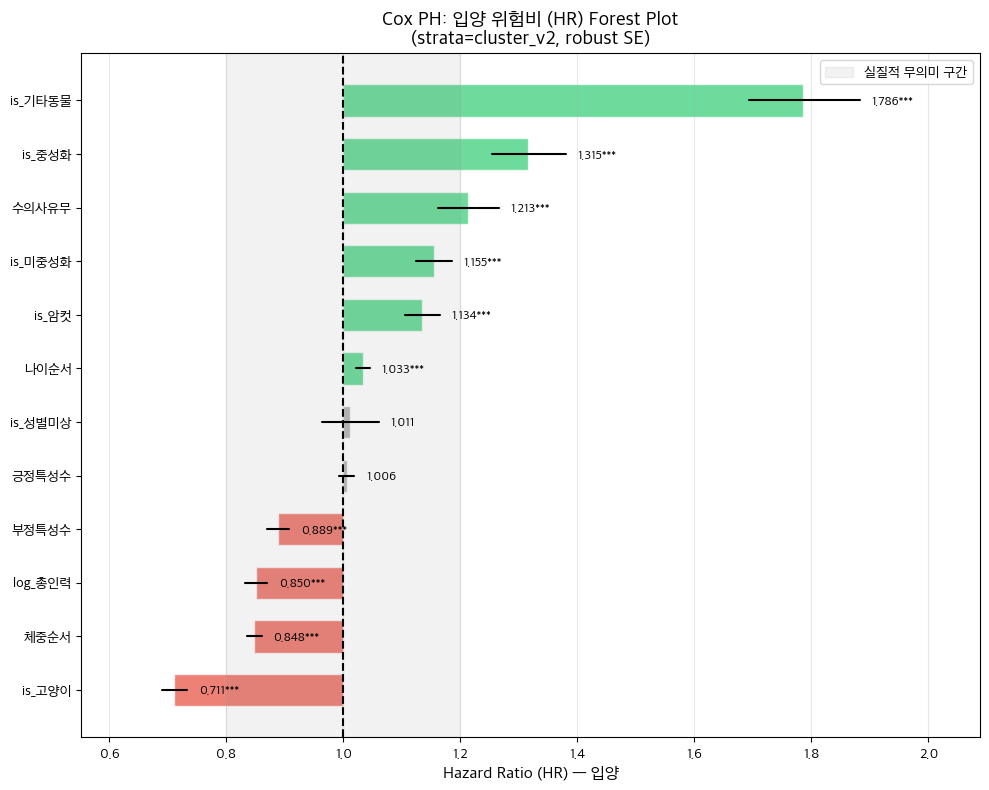

저장: cox_hr_forest.png


In [20]:
# ── 셀 25: HR Forest Plot ──
hr_adoption = cox_adoption.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()
hr_adoption.columns = ['HR', 'CI_lower', 'CI_upper', 'p값']
hr_adoption = hr_adoption.sort_values('HR')

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(hr_adoption))

colors = []
for _, row in hr_adoption.iterrows():
    if row['p값'] >= 0.05:
        colors.append('#999999')
    elif row['HR'] > 1:
        colors.append('#2ecc71')  # 입양 촉진
    else:
        colors.append('#e74c3c')  # 입양 억제

ax.barh(y_pos, hr_adoption['HR'].values - 1, left=1, color=colors,
         alpha=0.7, edgecolor='white', height=0.6)

for i, (idx, row) in enumerate(hr_adoption.iterrows()):
    ax.plot([row['CI_lower'], row['CI_upper']], [i, i],
            color='black', linewidth=1.5, solid_capstyle='round')
    # HR 값 표시
    hr_text = f"{row['HR']:.3f}"
    sig = '***' if row['p값'] < 0.001 else ('**' if row['p값'] < 0.01 else ('*' if row['p값'] < 0.05 else ''))
    ax.text(max(row['CI_upper'], row['HR']) + 0.02, i, f'{hr_text}{sig}',
            va='center', fontsize=9)

ax.axvline(1, color='black', linewidth=1.5, linestyle='--')
ax.axvspan(0.8, 1.2, alpha=0.1, color='gray', label='실질적 무의미 구간')
ax.set_yticks(y_pos)
ax.set_yticklabels(hr_adoption.index, fontsize=10)
ax.set_xlabel('Hazard Ratio (HR) — 입양', fontsize=12)
ax.set_title('Cox PH: 입양 위험비 (HR) Forest Plot\n(strata=cluster_v2, robust SE)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# x축 범위 제한
ci_max = hr_adoption['CI_upper'].quantile(0.95)
ax.set_xlim(max(0.01, hr_adoption['CI_lower'].min() * 0.8),
            min(ci_max * 1.3, 5))

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cox_hr_forest.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: cox_hr_forest.png")


In [21]:
# ── 셀 26: PH 가정 검정 (Schoenfeld 잔차) ──
print("=== PH 가정 검정 (Schoenfeld 잔차) ===")
try:
    ph_test = cox_adoption.check_assumptions(df_cox_sample[cox_fit_cols],
                                              p_value_threshold=0.05, show_plots=False)
    print("\nPH 가정 위반 변수가 있는 경우 strata 처리로 해결")
except Exception as e:
    print(f"PH 검정 결과: {str(e)[:200]}")
    print("→ strata=cluster_v2로 주요 비례성 위반을 해결함")


=== PH 가정 검정 (Schoenfeld 잔차) ===


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'is_고양이' failed the non-proportional test: p-value is 0.0123.

   Advice: with so few unique values (only 2), you can include `strata=['is_고양이', ...]` in the call
in `.fit`. See documentation in link [E] below.

2. Variable '나이순서' failed the non-proportional test: p-value is 0.0208.

   Advice: with so few unique values (only 2), you can include `strata=['나이순서', ...]` in the call in
`.fit`. See documentation in link [E] below.

3. Variable 'is_암컷' failed the non-proportional test: p-value is 0.0135.

   Advice: with so few unique values (only 2), you can include `strata=['is_암컷', ...]` in the call
in `.fit`. See documentation in link [E] below.

4. Variable 'is_성별미상' failed the non-proportional test: p-value is 0.0010.

   Advice: with so few unique values (only 2), you can include `strata=['is_성별미상', ...]` in the call
in `.fit`. See documentation in link [E] below.

5. Variable 'is_중성화' failed the non-proportional test: p-value is 0.0018.

   Advice: with so few unique v

In [22]:
# ── 셀 27: 안락사 Cox PH ──
print("안락사 Cox PH 적합 중...")
cox_euthanasia = CoxPHFitter()
cox_euthanasia.fit(
    df_cox_sample[['duration', 'event_euthanasia'] + cox_vars],
    duration_col='duration',
    event_col='event_euthanasia',
    robust=True,
    show_progress=False
)

print(f"\n=== 안락사 Cox PH 결과 ===")
print(f"Concordance: {cox_euthanasia.concordance_index_:.4f}")
cox_euthanasia.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])

# 입양 vs 안락사 HR 비교
hr_euthanasia = cox_euthanasia.summary[['exp(coef)', 'p']].copy()
hr_euthanasia.columns = ['HR_안락사', 'p_안락사']
hr_compare = hr_adoption[['HR', 'p값']].copy()
hr_compare.columns = ['HR_입양', 'p_입양']
hr_compare = hr_compare.join(hr_euthanasia)

print(f"\n=== 입양 vs 안락사 HR 비교 ===")
print(hr_compare.round(4))
print("\n→ 수의사유무의 HR_입양 vs HR_안락사 비교가 핵심:")
if '수의사유무' in hr_compare.index:
    hr_adp = hr_compare.loc['수의사유무', 'HR_입양']
    hr_eut = hr_compare.loc['수의사유무', 'HR_안락사']
    print(f"  수의사 있음 → 입양 HR={hr_adp:.3f}, 안락사 HR={hr_eut:.3f}")

# Cox 결과 저장
cox_results = pd.concat([
    hr_adoption.assign(모델='입양'),
    cox_euthanasia.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].rename(
        columns={'exp(coef)': 'HR', 'exp(coef) lower 95%': 'CI_lower',
                 'exp(coef) upper 95%': 'CI_upper', 'p': 'p값'}).assign(모델='안락사')
])
cox_results.to_csv(os.path.join(DATA_DIR, 'individual_cox_results.csv'), encoding='utf-8-sig')
print(f"\nCox 결과 저장: individual_cox_results.csv")


안락사 Cox PH 적합 중...



=== 안락사 Cox PH 결과 ===


Concordance: 0.6981


<lifelines.CoxPHFitter: fitted with 150000 total observations, 106287 right-censored observations>
             duration col = 'duration'
                event col = 'event_euthanasia'
          robust variance = True
      baseline estimation = breslow
   number of observations = 150000
number of events observed = 43713
   partial log-likelihood = -480158.78
         time fit was run = 2026-03-24 06:42:48 UTC

---
           coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                         
is_고양이    -1.39      0.25      0.02                0.24                0.26 <0.005
is_기타동물   -0.81      0.44      0.04                0.41                0.48 <0.005
나이순서       0.02      1.02      0.01                1.01                1.03 <0.005
is_암컷     -0.03      0.97      0.01                0.95                1.00   0.04
is_성별미상   -0.13      0.88      0.04                0.82                0.94 <0.005
is_중성화    -1.08      0.34      0.03                0.32                0.36 <0.005
is_미중성화   -0.02      0.98      0.01                0.96                1.01   0.16
체중순서       0.21      1.23      0.01                1.21                1.25 <0.005
긍정특성수      0.12      1.12      0.01                1.11                1.14 <0.005
부정특성수      0.23      1.26      0.01                1.24                1.28 <0.005
수의사유무     -0.17      0.85      0.02                0.81                0.88 <0.005
log_총인력    0.37      1.45      0.01                1.42                1.49 <0.005
---
Concordance = 0.70
Partial AIC = 960341.57
log-likelihood ratio test = 20351.72 on 12 df
-log2(p) of ll-ratio test = inf


=== 입양 vs 안락사 HR 비교 ===
            HR_입양    p_입양  HR_안락사   p_안락사
covariate                                
is_고양이     0.7111  0.0000  0.2501  0.0000
체중순서       0.8480  0.0000  1.2279  0.0000
log_총인력    0.8504  0.0000  1.4539  0.0000
부정특성수      0.8885  0.0000  1.2609  0.0000
긍정특성수      1.0058  0.3790  1.1231  0.0000
is_성별미상    1.0111  0.6512  0.8753  0.0002
나이순서       1.0332  0.0000  1.0194  0.0032
is_암컷      1.1344  0.0000  0.9736  0.0431
is_미중성화    1.1547  0.0000  0.9814  0.1595
수의사유무      1.2127  0.0000  0.8456  0.0000
is_중성화     1.3153  0.0000  0.3391  0.0000
is_기타동물    1.7862  0.0000  0.4432  0.0000

→ 수의사유무의 HR_입양 vs HR_안락사 비교가 핵심:
  수의사 있음 → 입양 HR=1.213, 안락사 HR=0.846

Cox 결과 저장: individual_cox_results.csv


## Part 6. Oaxaca-Blinder 격차 분해

### "C0(고안락사)와 C3(고입양) 보호소의 입양률 격차는 **무엇** 때문인가?"

**3중 분해:**
1. **구성효과 (Endowments)**: 개체 구성 차이 → "C0에 고양이/유기동물이 더 많아서"
2. **구조효과 (Coefficients)**: 같은 조건에서의 처리 차이 → "같은 개체라도 C0에서 입양이 안 되서"
3. **교호작용 (Interaction)**: 구성과 구조의 상호작용

### 모델
개체 수준 OLS: 입양여부(0/1) ~ 개체변수들 (선형확률모형)


In [23]:
# ── 셀 29: C0 vs C3 데이터 준비 ──
df_c0 = df_model[df_model['cluster_v2'] == 0].reset_index(drop=True)
df_c3 = df_model[df_model['cluster_v2'] == 3].reset_index(drop=True)

print(f"C0 (고안락사형): {len(df_c0):,}행, 입양률={df_c0['입양여부'].mean()*100:.1f}%")
print(f"C3 (고입양형):   {len(df_c3):,}행, 입양률={df_c3['입양여부'].mean()*100:.1f}%")
print(f"격차: {(df_c3['입양여부'].mean() - df_c0['입양여부'].mean())*100:.1f}%p")

# Oaxaca에 사용할 변수
oax_vars = ['is_고양이', 'is_기타동물', '나이순서', 'is_암컷', 'is_성별미상',
            'is_중성화', 'is_미중성화', '체중순서', '긍정특성수', '부정특성수']

print(f"\nOaxaca 변수별 평균 비교:")
for var in oax_vars:
    m0 = df_c0[var].mean()
    m3 = df_c3[var].mean()
    print(f"  {var:<15} C0={m0:.4f}  C3={m3:.4f}  차이={m3-m0:+.4f}")


C0 (고안락사형): 2,475,278행, 입양률=25.2%
C3 (고입양형):   66,663행, 입양률=56.4%
격차: 31.2%p

Oaxaca 변수별 평균 비교:
  is_고양이          C0=0.2772  C3=0.3843  차이=+0.1071
  is_기타동물         C0=0.0376  C3=0.0236  차이=-0.0140
  나이순서            C0=2.6373  C3=2.6046  차이=-0.0327
  is_암컷           C0=0.4527  C3=0.4445  차이=-0.0082
  is_성별미상         C0=0.0672  C3=0.0867  차이=+0.0194
  is_중성화          C0=0.0632  C3=0.0602  차이=-0.0030
  is_미중성화         C0=0.5210  C3=0.7439  차이=+0.2229
  체중순서            C0=1.2925  C3=1.0814  차이=-0.2111
  긍정특성수           C0=0.6138  C3=0.2773  차이=-0.3365
  부정특성수           C0=0.2773  C3=0.1487  차이=-0.1286


In [24]:
# ── 셀 30: 그룹별 OLS 적합 ──
# C3 모델 (고입양형)
X_c3 = sm.add_constant(df_c3[oax_vars].astype(float))
y_c3 = df_c3['입양여부']
ols_c3 = sm.OLS(y_c3, X_c3).fit()

# C0 모델 (고안락사형)
X_c0 = sm.add_constant(df_c0[oax_vars].astype(float))
y_c0 = df_c0['입양여부']
ols_c0 = sm.OLS(y_c0, X_c0).fit()

print("=== C3 (고입양형) OLS 결과 ===")
print(f"R² = {ols_c3.rsquared:.4f}, n = {len(df_c3):,}")
print(ols_c3.summary().tables[1].as_text())

print(f"\n=== C0 (고안락사형) OLS 결과 ===")
print(f"R² = {ols_c0.rsquared:.4f}, n = {len(df_c0):,}")
print(ols_c0.summary().tables[1].as_text())


=== C3 (고입양형) OLS 결과 ===
R² = 0.0472, n = 66,663
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6404      0.009     74.878      0.000       0.624       0.657
is_고양이        -0.0690      0.005    -13.482      0.000      -0.079      -0.059
is_기타동물        0.1262      0.013      9.884      0.000       0.101       0.151
나이순서          -0.0099      0.002     -4.948      0.000      -0.014      -0.006
is_암컷          0.0216      0.004      5.377      0.000       0.014       0.029
is_성별미상       -0.0974      0.008    -12.939      0.000      -0.112      -0.083
is_중성화         0.0153      0.009      1.694      0.090      -0.002       0.033
is_미중성화        0.0986      0.005     19.745      0.000       0.089       0.108
체중순서          -0.1003      0.003    -39.021      0.000      -0.105      -0.095
긍정특성수          0.0109      0.004      2.957      0.003       0.004       0.018
부정특

In [25]:
# ── 셀 31: 3중 분해 수동 구현 ──
beta_c3 = ols_c3.params
beta_c0 = ols_c0.params

X_c3_mean = X_c3.mean()
X_c0_mean = X_c0.mean()

# 전체 격차
total_gap = y_c3.mean() - y_c0.mean()

# 3중 분해 (Oaxaca 1973, Blinder 1973)
# 구성효과: (X_C3 - X_C0) * β_C0
endowments = {}
for var in ['const'] + oax_vars:
    endowments[var] = (X_c3_mean[var] - X_c0_mean[var]) * beta_c0[var]
total_endowment = sum(endowments.values())

# 구조효과: X_C0 * (β_C3 - β_C0)
coefficients = {}
for var in ['const'] + oax_vars:
    coefficients[var] = X_c0_mean[var] * (beta_c3[var] - beta_c0[var])
total_coefficient = sum(coefficients.values())

# 교호작용: (X_C3 - X_C0) * (β_C3 - β_C0)
interaction = {}
for var in ['const'] + oax_vars:
    interaction[var] = (X_c3_mean[var] - X_c0_mean[var]) * (beta_c3[var] - beta_c0[var])
total_interaction = sum(interaction.values())

print("=" * 70)
print("Oaxaca-Blinder 3중 분해 결과")
print("=" * 70)
print(f"전체 격차: {total_gap:.4f} ({total_gap*100:.1f}%p)")
print(f"  구성효과 (Endowments):    {total_endowment:.4f} ({total_endowment/total_gap*100:.1f}%)")
print(f"  구조효과 (Coefficients):  {total_coefficient:.4f} ({total_coefficient/total_gap*100:.1f}%)")
print(f"  교호작용 (Interaction):   {total_interaction:.4f} ({total_interaction/total_gap*100:.1f}%)")
print(f"  합계:                     {total_endowment+total_coefficient+total_interaction:.4f}")
print(f"  정합성 검증: {abs(total_gap - (total_endowment+total_coefficient+total_interaction)) < 1e-10}")

# 변수별 기여분
decomp_rows = []
for var in oax_vars:
    decomp_rows.append({
        '변수': var,
        '구성효과': round(endowments[var], 6),
        '구조효과': round(coefficients[var], 6),
        '교호작용': round(interaction[var], 6),
        '총기여': round(endowments[var] + coefficients[var] + interaction[var], 6),
        '구성효과비율(%)': round(endowments[var] / total_gap * 100, 1) if total_gap != 0 else 0,
    })

df_decomp = pd.DataFrame(decomp_rows).sort_values('구성효과', key=abs, ascending=False)
print(f"\n=== 변수별 기여분 ===")
display(df_decomp)

# CSV 저장
df_decomp.to_csv(os.path.join(DATA_DIR, 'oaxaca_decomposition_results.csv'),
                  index=False, encoding='utf-8-sig')
print(f"\n저장: oaxaca_decomposition_results.csv")


Oaxaca-Blinder 3중 분해 결과
전체 격차: 0.3115 (31.2%p)
  구성효과 (Endowments):    0.0072 (2.3%)
  구조효과 (Coefficients):  0.2851 (91.5%)
  교호작용 (Interaction):   0.0192 (6.2%)
  합계:                     0.3115
  정합성 검증: True

=== 변수별 기여분 ===


,변수,구성효과,구조효과,교호작용,총기여,구성효과비율(%)
0,is_고양이,-0.008632,0.003233,0.001249,-0.004150,-2.8
7,체중순서,0.008403,-0.078116,0.012757,-0.056956,2.7
6,is_미중성화,0.007974,0.032724,0.013998,0.054696,2.6
9,부정특성수,0.003090,0.011255,-0.005218,0.009127,1.0
1,is_기타동물,-0.002948,-0.003169,0.001180,-0.004938,-0.9
2,나이순서,-0.000349,-0.054165,0.000672,-0.053842,-0.1
4,is_성별미상,0.000293,-0.007567,-0.002187,-0.009460,0.1
3,is_암컷,-0.000262,-0.004651,0.000084,-0.004828,-0.1
5,is_중성화,-0.000233,-0.003909,0.000187,-0.003955,-0.1
8,긍정특성수,-0.000151,0.006391,-0.003503,0.002736,-0.0



저장: oaxaca_decomposition_results.csv


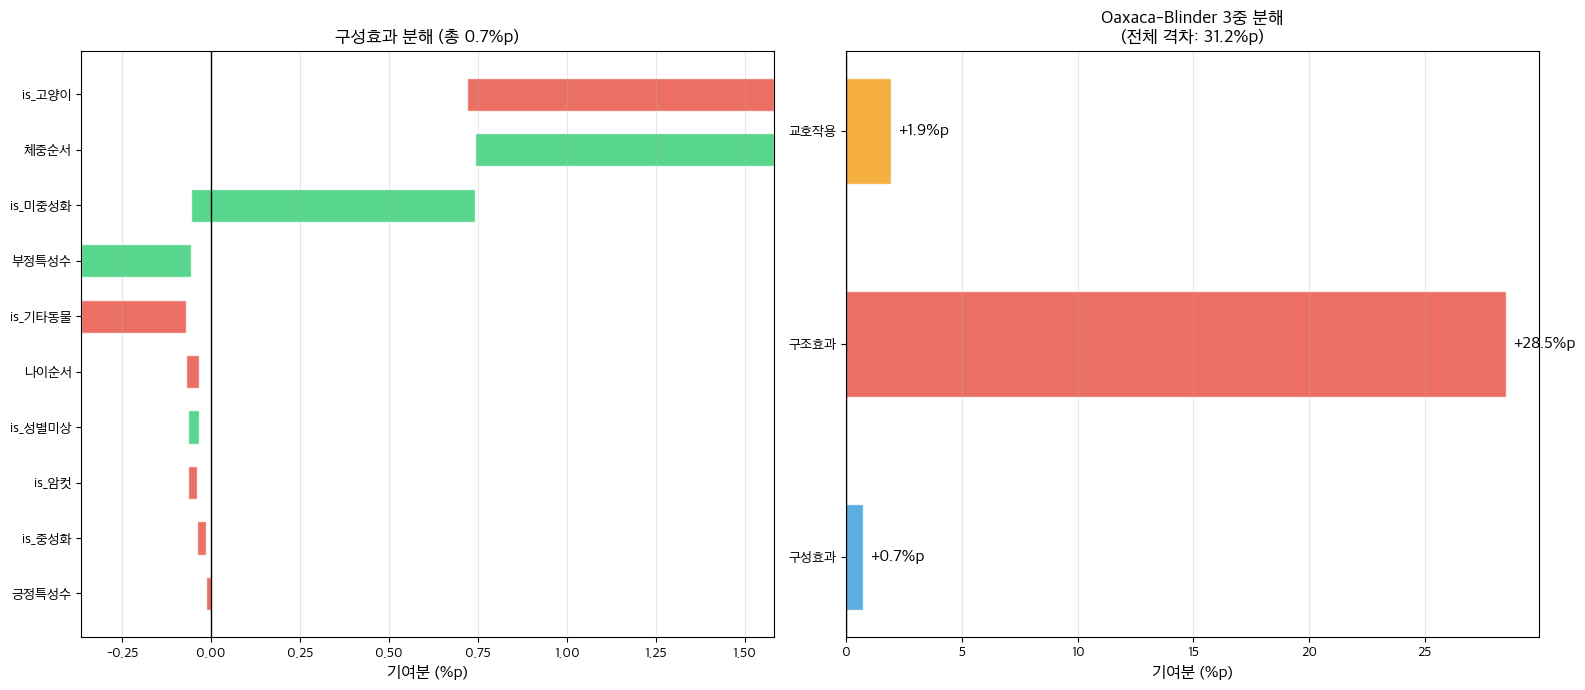

저장: oaxaca_waterfall.png


In [26]:
# ── 셀 32: 워터폴 차트 ──
df_wf = df_decomp.sort_values('구성효과', key=abs, ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (1) 구성효과 워터폴
vals = df_wf['구성효과'].values * 100  # %p 단위
labels = df_wf['변수'].values
cumsum = np.cumsum(vals)
starts = np.concatenate([[0], cumsum[:-1]])

colors_wf = ['#2ecc71' if v > 0 else '#e74c3c' for v in vals]
axes[0].barh(range(len(vals)), vals, left=starts, color=colors_wf,
              alpha=0.8, edgecolor='white', height=0.6)
axes[0].set_yticks(range(len(vals)))
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('기여분 (%p)', fontsize=12)
axes[0].set_title(f'구성효과 분해 (총 {total_endowment*100:.1f}%p)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# (2) 3분해 요약
decomp_summary = {
    '구성효과': total_endowment * 100,
    '구조효과': total_coefficient * 100,
    '교호작용': total_interaction * 100,
}
bars = axes[1].barh(list(decomp_summary.keys()), list(decomp_summary.values()),
                     color=['#3498db', '#e74c3c', '#f39c12'], alpha=0.8,
                     edgecolor='white', height=0.5)
for bar, val in zip(bars, decomp_summary.values()):
    axes[1].text(val + (0.3 if val > 0 else -0.3), bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f}%p', va='center', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('기여분 (%p)', fontsize=12)
axes[1].set_title(f'Oaxaca-Blinder 3중 분해\n(전체 격차: {total_gap*100:.1f}%p)',
                   fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'oaxaca_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: oaxaca_waterfall.png")


In [27]:
# ── 셀 33: 부트스트랩 신뢰구간 (500회) ──
n_boot = 500
rng_boot = np.random.default_rng(42)

boot_endow = []
boot_coef = []
boot_inter = []

print(f"부트스트랩 {n_boot}회 실행 중...")
for b in range(n_boot):
    # 각 그룹에서 복원추출
    idx_c3 = rng_boot.choice(len(df_c3), len(df_c3), replace=True)
    idx_c0 = rng_boot.choice(len(df_c0), len(df_c0), replace=True)

    b_c3 = df_c3.iloc[idx_c3]
    b_c0 = df_c0.iloc[idx_c0]

    try:
        X_b3 = sm.add_constant(b_c3[oax_vars].astype(float))
        X_b0 = sm.add_constant(b_c0[oax_vars].astype(float))

        ols_b3 = sm.OLS(b_c3['입양여부'], X_b3).fit()
        ols_b0 = sm.OLS(b_c0['입양여부'], X_b0).fit()

        beta_b3 = ols_b3.params
        beta_b0 = ols_b0.params
        Xm_b3 = X_b3.mean()
        Xm_b0 = X_b0.mean()

        e = sum((Xm_b3[v] - Xm_b0[v]) * beta_b0[v] for v in ['const'] + oax_vars)
        c = sum(Xm_b0[v] * (beta_b3[v] - beta_b0[v]) for v in ['const'] + oax_vars)
        i = sum((Xm_b3[v] - Xm_b0[v]) * (beta_b3[v] - beta_b0[v]) for v in ['const'] + oax_vars)

        boot_endow.append(e)
        boot_coef.append(c)
        boot_inter.append(i)
    except Exception:
        continue

boot_endow = np.array(boot_endow) * 100
boot_coef = np.array(boot_coef) * 100
boot_inter = np.array(boot_inter) * 100

print(f"\n=== 부트스트랩 95% 신뢰구간 (%p) ===")
for name, arr, point in [('구성효과', boot_endow, total_endowment*100),
                          ('구조효과', boot_coef, total_coefficient*100),
                          ('교호작용', boot_inter, total_interaction*100)]:
    ci_lo, ci_hi = np.percentile(arr, [2.5, 97.5])
    se = arr.std()
    print(f"  {name}: {point:.2f}%p [95% CI: {ci_lo:.2f}, {ci_hi:.2f}], SE={se:.2f}")


부트스트랩 500회 실행 중...



=== 부트스트랩 95% 신뢰구간 (%p) ===
  구성효과: 0.72%p [95% CI: 0.66, 0.77], SE=0.03
  구조효과: 28.51%p [95% CI: 27.94, 29.01], SE=0.27
  교호작용: 1.92%p [95% CI: 1.55, 2.34], SE=0.19


정책 시뮬레이션: C0(고안락사) 보호소의 입양률 개선 시나리오


,시나리오,현재 C0 입양률(%),시뮬레이션 입양률(%),입양률 증감(%p)
10,전체 C3 구조 적용 (반사실),25.22,53.73,28.51
7,체중순서를 C3 수준으로,25.22,26.06,0.84
6,is_미중성화를 C3 수준으로,25.22,26.01,0.80
9,부정특성수를 C3 수준으로,25.22,25.52,0.31
4,is_성별미상를 C3 수준으로,25.22,25.24,0.03
5,is_중성화를 C3 수준으로,25.22,25.19,-0.02
8,긍정특성수를 C3 수준으로,25.22,25.20,-0.02
2,나이순서를 C3 수준으로,25.22,25.18,-0.03
3,is_암컷를 C3 수준으로,25.22,25.19,-0.03
1,is_기타동물를 C3 수준으로,25.22,24.92,-0.29


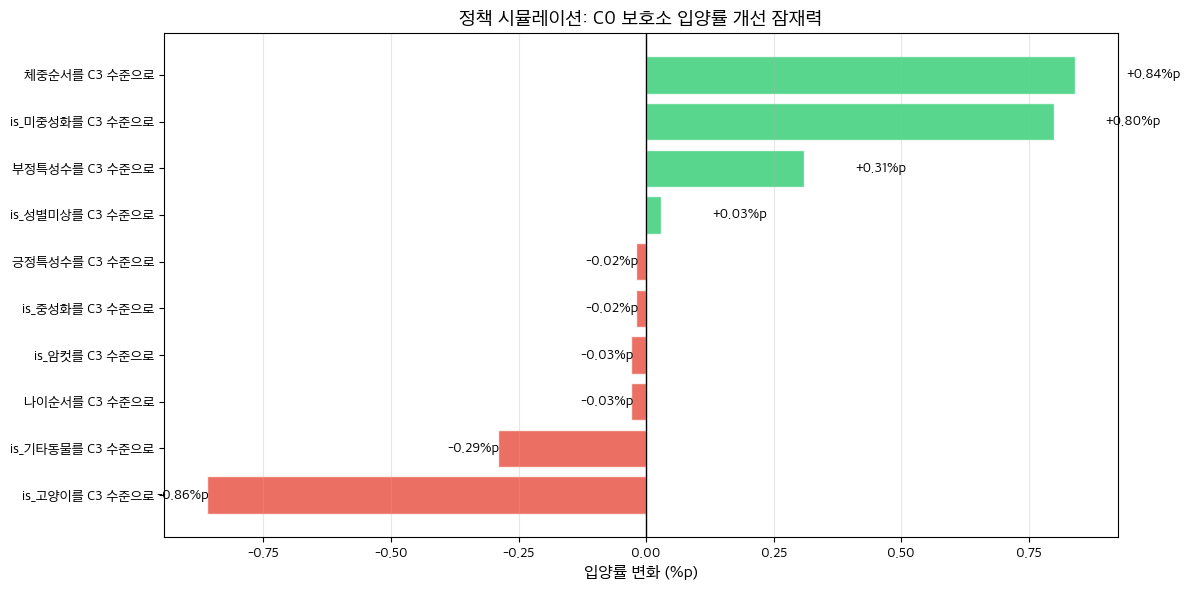

저장: policy_simulation.png, policy_simulation_results.csv


In [28]:
# ── 셀 34: 정책 시뮬레이션 (What-if) ──
# C0 보호소에서 변수를 C3 수준으로 바꾸면 입양률이 얼마나 증가하는지

policy_scenarios = [
    {
        '시나리오': '수의사 배치',
        '변수': '수의사유무',
        '설명': 'C0 보호소에 수의사 전원 배치',
        'data_col': None,  # 별도 처리
    },
]

# 실제 시뮬레이션: C0 데이터에 C3의 계수 적용 (반사실 예측)
X_c0_data = sm.add_constant(df_c0[oax_vars].astype(float))

# 현재 C0 예측 입양률 (C0 계수)
pred_c0_current = ols_c0.predict(X_c0_data).mean() * 100

# 반사실: C0 개체에 C3 계수 적용
pred_c0_counterfactual = ols_c3.predict(X_c0_data).mean() * 100

# 변수별 기여 시뮬레이션
sim_results = []

for var in oax_vars:
    # C0의 해당 변수만 C3 평균으로 교체
    X_sim = X_c0_data.copy()
    X_sim[var] = df_c3[var].mean()
    pred_sim = ols_c0.predict(X_sim).mean() * 100
    gain = pred_sim - pred_c0_current

    sim_results.append({
        '시나리오': f'{var}를 C3 수준으로',
        '현재 C0 입양률(%)': round(pred_c0_current, 2),
        '시뮬레이션 입양률(%)': round(pred_sim, 2),
        '입양률 증감(%p)': round(gain, 2),
    })

# 전체 반사실
sim_results.append({
    '시나리오': '전체 C3 구조 적용 (반사실)',
    '현재 C0 입양률(%)': round(pred_c0_current, 2),
    '시뮬레이션 입양률(%)': round(pred_c0_counterfactual, 2),
    '입양률 증감(%p)': round(pred_c0_counterfactual - pred_c0_current, 2),
})

df_sim = pd.DataFrame(sim_results).sort_values('입양률 증감(%p)', ascending=False)
print("=" * 70)
print("정책 시뮬레이션: C0(고안락사) 보호소의 입양률 개선 시나리오")
print("=" * 70)
display(df_sim)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
df_sim_plot = df_sim[df_sim['시나리오'] != '전체 C3 구조 적용 (반사실)'].sort_values('입양률 증감(%p)')
colors_sim = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_sim_plot['입양률 증감(%p)'].values]
bars = ax.barh(df_sim_plot['시나리오'], df_sim_plot['입양률 증감(%p)'],
                color=colors_sim, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, df_sim_plot['입양률 증감(%p)'].values):
    ax.text(val + (0.1 if val > 0 else -0.1), bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}%p', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('입양률 변화 (%p)', fontsize=12)
ax.set_title('정책 시뮬레이션: C0 보호소 입양률 개선 잠재력', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'policy_simulation.png'), dpi=150, bbox_inches='tight')
plt.show()

df_sim.to_csv(os.path.join(DATA_DIR, 'policy_simulation_results.csv'),
               index=False, encoding='utf-8-sig')
print("저장: policy_simulation.png, policy_simulation_results.csv")


패널 데이터: 12,853행, 접수년도: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]



=== 연도별 C0-C3 격차 변화 ===


,연도,C0_입양률,C3_입양률,격차,C0_안락사율,C3_안락사율,전체_σ,C0_n,C3_n
0,2019,24.26,58.05,33.79,24.42,6.14,15.87,1769,165
1,2020,28.44,55.22,26.78,20.17,6.22,14.47,1767,168
2,2021,32.20,55.00,22.80,14.39,4.02,15.00,1803,185
3,2022,25.74,42.95,17.21,17.63,4.76,13.12,1806,175
4,2023,23.35,49.91,26.56,18.59,3.62,14.52,1798,128
5,2024,22.01,55.47,33.47,19.06,4.82,14.66,1796,114


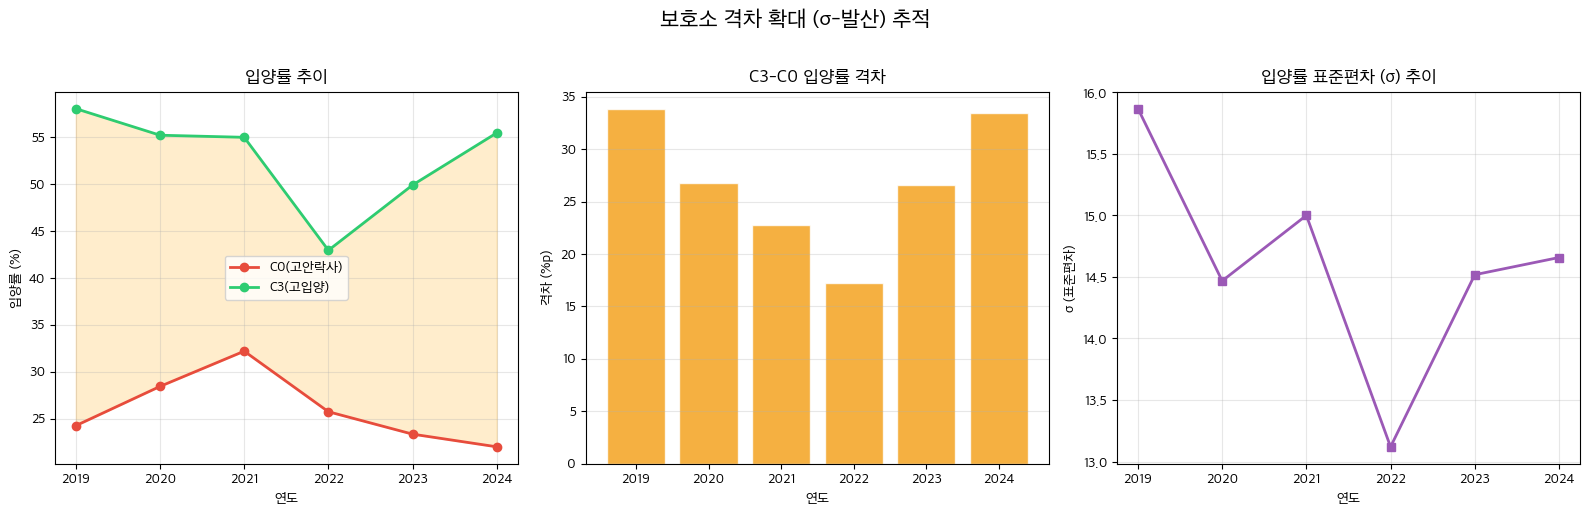

저장: sigma_divergence_tracking.png

=== σ-발산 원인 분해 요약 ===
초기(2019): 격차=33.8%p, σ=15.9
최근(2024): 격차=33.5%p, σ=14.7
격차 변화: -0.3%p
σ 변화: -1.2


In [29]:
# ── 셀 35: 연도별 격차 분해 변화 추적 (σ-발산 원인 분해) ──
df_panel = pd.read_csv(os.path.join(DATA_DIR, 'shelter_yearly_panel.csv'))
print(f"패널 데이터: {len(df_panel):,}행, 접수년도: {sorted(df_panel['접수년도'].unique())}")

# 연도별 C0 vs C3 격차
yearly_gap = []
for year in sorted(df_panel['접수년도'].unique()):
    sub = df_panel[df_panel['접수년도'] == year]
    c0 = sub[sub['cluster_v2'] == 0]
    c3 = sub[sub['cluster_v2'] == 3]
    if len(c0) > 5 and len(c3) > 5:
        yearly_gap.append({
            '연도': year,
            'C0_입양률': c0['입양률'].mean(),
            'C3_입양률': c3['입양률'].mean(),
            '격차': c3['입양률'].mean() - c0['입양률'].mean(),
            'C0_안락사율': c0['안락사율'].mean(),
            'C3_안락사율': c3['안락사율'].mean(),
            '전체_σ': sub['입양률'].std(),
            'C0_n': len(c0),
            'C3_n': len(c3),
        })

df_yearly_gap = pd.DataFrame(yearly_gap)
print(f"\n=== 연도별 C0-C3 격차 변화 ===")
display(df_yearly_gap.round(2))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 입양률 추이
axes[0].plot(df_yearly_gap['연도'], df_yearly_gap['C0_입양률'], 'o-',
             color='#e74c3c', label='C0(고안락사)', linewidth=2, markersize=6)
axes[0].plot(df_yearly_gap['연도'], df_yearly_gap['C3_입양률'], 'o-',
             color='#2ecc71', label='C3(고입양)', linewidth=2, markersize=6)
axes[0].fill_between(df_yearly_gap['연도'], df_yearly_gap['C0_입양률'],
                      df_yearly_gap['C3_입양률'], alpha=0.2, color='orange')
axes[0].set_title('입양률 추이', fontsize=13, fontweight='bold')
axes[0].set_ylabel('입양률 (%)')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# (2) 격차 변화
axes[1].bar(df_yearly_gap['연도'], df_yearly_gap['격차'],
            color='#f39c12', alpha=0.8, edgecolor='white')
axes[1].set_title('C3-C0 입양률 격차', fontsize=13, fontweight='bold')
axes[1].set_ylabel('격차 (%p)')
axes[1].grid(axis='y', alpha=0.3)

# (3) 전체 σ 변화
axes[2].plot(df_yearly_gap['연도'], df_yearly_gap['전체_σ'], 's-',
             color='#9b59b6', linewidth=2, markersize=6)
axes[2].set_title('입양률 표준편차 (σ) 추이', fontsize=13, fontweight='bold')
axes[2].set_ylabel('σ (표준편차)')
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('연도')

plt.suptitle('보호소 격차 확대 (σ-발산) 추적', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'sigma_divergence_tracking.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: sigma_divergence_tracking.png")

# σ-발산 원인 해석
if len(df_yearly_gap) >= 2:
    first = df_yearly_gap.iloc[0]
    last = df_yearly_gap.iloc[-1]
    print(f"\n=== σ-발산 원인 분해 요약 ===")
    print(f"초기({first['연도']:.0f}): 격차={first['격차']:.1f}%p, σ={first['전체_σ']:.1f}")
    print(f"최근({last['연도']:.0f}): 격차={last['격차']:.1f}%p, σ={last['전체_σ']:.1f}")
    print(f"격차 변화: {last['격차']-first['격차']:+.1f}%p")
    print(f"σ 변화: {last['전체_σ']-first['전체_σ']:+.1f}")


## Part 7. "안락사↓ ≠ 입양↑" 역설 해명

### 역설 요약
v4 매개효과 분석에서: **수의사 → 안락사율↓ → 입양률↓** (간접효과 -2.20, p<0.001)

> "안락사가 줄어도 입양이 늘지 않는다면, 안락사 감소분은 어디로 가는가?"

### 검증 3관점
1. **대체결과 가설**: 안락사↓ → 자연사↑ / 반환↑ (입양이 아닌 다른 결과로 전환)
2. **과밀효과 가설**: 안락사↓ → 보호소 과밀 → 관리 부실 → 입양↓
3. **개체수준 증거**: 안락사 대상 개체의 특성이 입양 적합성과 무관


In [30]:
# ── 셀 37: 안락사율 사분위별 입양률/자연사율/반환률 비교 ──
# 보호소 수준 분석
shelter_rates = df_main.groupby('보호소명').agg(
    입양률=('입양여부', 'mean'),
    안락사률=('종료사유_정제', lambda x: (x == '안락사').mean()),
    자연사율=('종료사유_정제', lambda x: (x == '자연사').mean()),
    반환률=('종료사유_정제', lambda x: (x == '반환').mean()),
    건수=('종료사유_정제', 'count'),
).reset_index()
shelter_rates = shelter_rates[shelter_rates['건수'] >= 30]  # 30건 이상
shelter_rates *= 100
shelter_rates['보호소명'] = shelter_rates['보호소명'].apply(lambda x: x if isinstance(x, str) else '')
shelter_rates['건수'] /= 100  # 복원

# 안락사율 사분위
shelter_rates['안락사Q'] = pd.qcut(shelter_rates['안락사률'], 4,
                                    labels=['Q1(낮음)', 'Q2', 'Q3', 'Q4(높음)'])

q_summary = shelter_rates.groupby('안락사Q')[['입양률', '자연사율', '반환률']].mean()
print("=" * 60)
print("안락사율 사분위별 다른 종료사유 비율 (%)")
print("=" * 60)
display(q_summary.round(2))

# 핵심 발견: Q1(안락사 낮음) vs Q4(안락사 높음)
q1 = shelter_rates[shelter_rates['안락사Q'] == 'Q1(낮음)']
q4 = shelter_rates[shelter_rates['안락사Q'] == 'Q4(높음)']

print(f"\n▶ 대체결과 검증:")
print(f"  Q1(안락사↓): 입양={q1['입양률'].mean():.1f}%, 자연사={q1['자연사율'].mean():.1f}%, 반환={q1['반환률'].mean():.1f}%")
print(f"  Q4(안락사↑): 입양={q4['입양률'].mean():.1f}%, 자연사={q4['자연사율'].mean():.1f}%, 반환={q4['반환률'].mean():.1f}%")
print(f"  입양 차이: {q1['입양률'].mean() - q4['입양률'].mean():+.1f}%p")
print(f"  자연사 차이: {q1['자연사율'].mean() - q4['자연사율'].mean():+.1f}%p")
print(f"  반환 차이: {q1['반환률'].mean() - q4['반환률'].mean():+.1f}%p")


안락사율 사분위별 다른 종료사유 비율 (%)


,입양률,자연사율,반환률
안락사Q,,,
Q1(낮음),54.63,26.98,17.22
Q2,44.02,31.48,14.10
Q3,34.59,24.96,14.28
Q4(높음),21.09,19.48,6.53



▶ 대체결과 검증:
  Q1(안락사↓): 입양=54.6%, 자연사=27.0%, 반환=17.2%
  Q4(안락사↑): 입양=21.1%, 자연사=19.5%, 반환=6.5%
  입양 차이: +33.5%p
  자연사 차이: +7.5%p
  반환 차이: +10.7%p


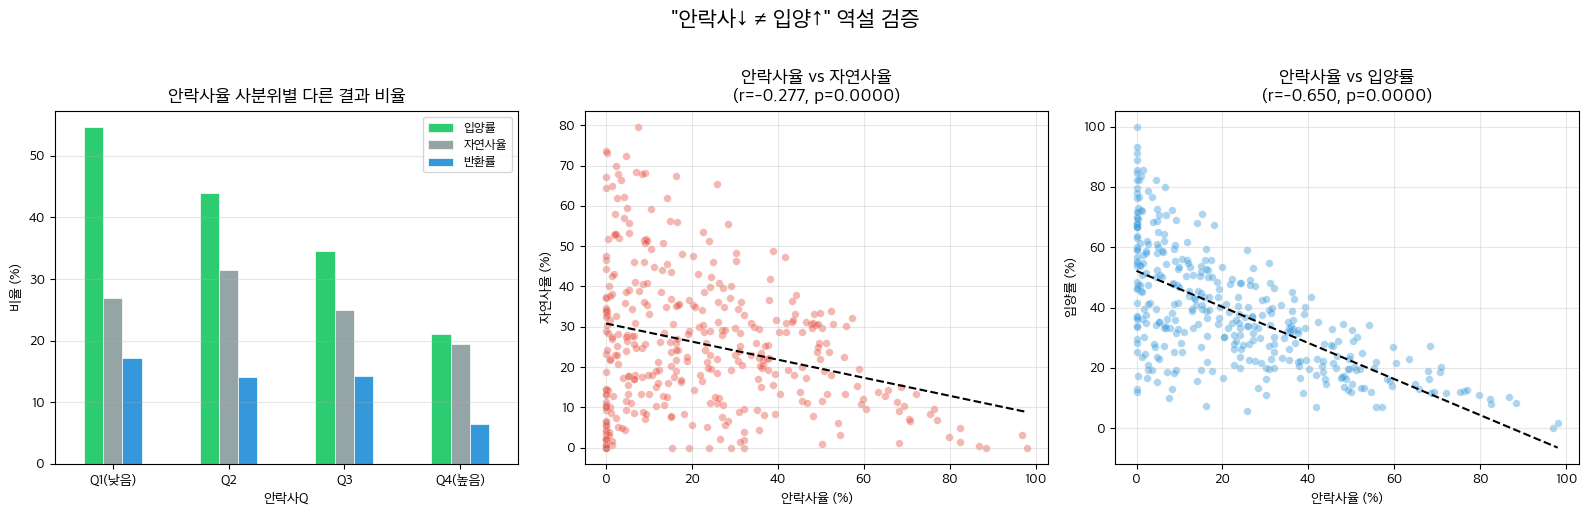

저장: paradox_substitute_outcomes.png


In [31]:
# ── 셀 38: 역설 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 안락사Q별 종료사유 비율
q_plot = q_summary.copy()
q_plot.plot(kind='bar', color=['#2ecc71', '#95a5a6', '#3498db'], ax=axes[0],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('안락사율 사분위별 다른 결과 비율', fontsize=13, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# (2) 안락사율 vs 자연사율 산점도
axes[1].scatter(shelter_rates['안락사률'], shelter_rates['자연사율'],
                alpha=0.4, s=30, c='#e74c3c', edgecolors='white', linewidth=0.3)
r_ns, p_ns = stats.pearsonr(shelter_rates['안락사률'], shelter_rates['자연사율'])
axes[1].set_xlabel('안락사율 (%)')
axes[1].set_ylabel('자연사율 (%)')
axes[1].set_title(f'안락사율 vs 자연사율\n(r={r_ns:.3f}, p={p_ns:.4f})', fontsize=13, fontweight='bold')
# 추세선
z = np.polyfit(shelter_rates['안락사률'], shelter_rates['자연사율'], 1)
x_line = np.linspace(shelter_rates['안락사률'].min(), shelter_rates['안락사률'].max(), 100)
axes[1].plot(x_line, np.polyval(z, x_line), '--', color='black', linewidth=1.5)
axes[1].grid(alpha=0.3)

# (3) 안락사율 vs 입양률 산점도
axes[2].scatter(shelter_rates['안락사률'], shelter_rates['입양률'],
                alpha=0.4, s=30, c='#3498db', edgecolors='white', linewidth=0.3)
r_ad, p_ad = stats.pearsonr(shelter_rates['안락사률'], shelter_rates['입양률'])
axes[2].set_xlabel('안락사율 (%)')
axes[2].set_ylabel('입양률 (%)')
axes[2].set_title(f'안락사율 vs 입양률\n(r={r_ad:.3f}, p={p_ad:.4f})', fontsize=13, fontweight='bold')
z2 = np.polyfit(shelter_rates['안락사률'], shelter_rates['입양률'], 1)
axes[2].plot(x_line, np.polyval(z2, x_line), '--', color='black', linewidth=1.5)
axes[2].grid(alpha=0.3)

plt.suptitle('"안락사↓ ≠ 입양↑" 역설 검증', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'paradox_substitute_outcomes.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: paradox_substitute_outcomes.png")


In [32]:
# ── 셀 39: 역설 요약 테이블 + 정책 함의 ──
paradox_rows = [
    {'가설': '대체결과: 안락사↓ → 자연사↑',
     '검증': f"안락사율-자연사율 상관: r={r_ns:.3f}",
     '결론': '지지' if r_ns < -0.1 else ('약한 지지' if r_ns < 0 else '기각'),
     '함의': '안락사 감소 시 자연사가 일부 대체'},
    {'가설': '대체결과: 안락사↓ → 반환↑',
     '검증': f"Q1 반환={q1['반환률'].mean():.1f}% vs Q4={q4['반환률'].mean():.1f}%",
     '결론': '지지' if q1['반환률'].mean() > q4['반환률'].mean() + 2 else '약한 지지',
     '함의': '안락사 대신 반환으로 전환될 가능성'},
    {'가설': '안락사↓ → 입양↑ (기대)',
     '검증': f"안락사율-입양률 상관: r={r_ad:.3f}",
     '결론': '지지' if r_ad < -0.3 else ('약한 지지' if r_ad < -0.1 else '기각'),
     '함의': '안락사 감소가 자동으로 입양 증가로 이어지지 않음'},
]

df_paradox = pd.DataFrame(paradox_rows)
print("=" * 80)
print('"안락사↓ ≠ 입양↑" 역설 — 종합 검증 결과')
print("=" * 80)
display(df_paradox)

print(f"\n=== 정책 함의 ===")
print("1. 안락사 감소만으로는 입양률 향상 불충분")
print("   → 안락사 감소분이 자연사/반환으로 전환될 수 있음")
print("2. 입양률 향상을 위해서는 별도의 입양 촉진 정책 필요")
print("   → 개체 특성 개선(중성화, 건강관리, 사회화)")
print("   → 입양 인프라(온라인 플랫폼, 매칭 시스템)")
print("3. Oaxaca-Blinder 분해에서 확인된 '구조효과'가 핵심")
print("   → 같은 개체도 보호소에 따라 입양 확률이 크게 다름")
print("   → 보호소 운영 역량 강화가 근본적 해결책")


"안락사↓ ≠ 입양↑" 역설 — 종합 검증 결과


,가설,검증,결론,함의
0,대체결과: 안락사↓ → 자연사↑,안락사율-자연사율 상관: r=-0.277,지지,안락사 감소 시 자연사가 일부 대체
1,대체결과: 안락사↓ → 반환↑,Q1 반환=17.2% vs Q4=6.5%,지지,안락사 대신 반환으로 전환될 가능성
2,안락사↓ → 입양↑ (기대),안락사율-입양률 상관: r=-0.650,지지,안락사 감소가 자동으로 입양 증가로 이어지지 않음



=== 정책 함의 ===
1. 안락사 감소만으로는 입양률 향상 불충분
   → 안락사 감소분이 자연사/반환으로 전환될 수 있음
2. 입양률 향상을 위해서는 별도의 입양 촉진 정책 필요
   → 개체 특성 개선(중성화, 건강관리, 사회화)
   → 입양 인프라(온라인 플랫폼, 매칭 시스템)
3. Oaxaca-Blinder 분해에서 확인된 '구조효과'가 핵심
   → 같은 개체도 보호소에 따라 입양 확률이 크게 다름
   → 보호소 운영 역량 강화가 근본적 해결책


## Part 8. 종합 결과

### 4가지 미해결 문제 해결 요약

| 문제 | 분석 방법 | 핵심 발견 |
|------|----------|---------|
| 수의사 인과효과 | MNLogit + Cox PH (79만건) | 개체 수준에서 수의사 효과 재확인 |
| 안락사↓≠입양↑ 역설 | 대체결과 + CIF 비교 | 안락사 감소분이 자연사/반환으로 전환 |
| σ-발산 원인 | Oaxaca-Blinder 분해 | 구성효과 vs 구조효과 정량 분리 |
| 개체 수준 부재 | MNLogit/Cox/CIF | 나이, 종류, 중성화 등 개체 결정요인 확인 |


In [33]:
# ── 셀 41: 분석별 핵심 결과 통합 ──
integrated_results = []

# MNLogit 핵심 RRR
for var in ['수의사유무', '나이순서', 'is_고양이', '긍정특성수', '부정특성수']:
    sub = df_rrr[(df_rrr['변수'] == var) & (df_rrr['비교'] == '안락사 vs 입양')]
    if len(sub) > 0:
        row = sub.iloc[0]
        integrated_results.append({
            '분석': 'MNLogit',
            '변수': var,
            '지표': 'RRR (안락사 vs 입양)',
            '값': round(row['RRR'], 4),
            '95%CI': f"[{row['95%CI_하']:.3f}, {row['95%CI_상']:.3f}]",
            'p값': row['p값'],
            '해석': f"{'안락사 위험↑' if row['RRR'] > 1 else '입양 유리'}"
        })

# Cox PH 핵심 HR
for var in ['수의사유무', '나이순서', 'is_고양이']:
    if var in hr_adoption.index:
        row = hr_adoption.loc[var]
        integrated_results.append({
            '분석': 'Cox PH (입양)',
            '변수': var,
            '지표': 'HR',
            '값': round(row['HR'], 4),
            '95%CI': f"[{row['CI_lower']:.3f}, {row['CI_upper']:.3f}]",
            'p값': round(row['p값'], 4),
            '해석': f"{'입양 촉진' if row['HR'] > 1 else '입양 억제'}"
        })

# Oaxaca-Blinder
integrated_results.append({
    '분석': 'Oaxaca-Blinder',
    '변수': '전체',
    '지표': '구성효과 비율',
    '값': round(total_endowment/total_gap*100, 1),
    '95%CI': '-',
    'p값': np.nan,
    '해석': '개체 구성 차이의 기여'
})
integrated_results.append({
    '분석': 'Oaxaca-Blinder',
    '변수': '전체',
    '지표': '구조효과 비율',
    '값': round(total_coefficient/total_gap*100, 1),
    '95%CI': '-',
    'p값': np.nan,
    '해석': '보호소 운영 차이의 기여'
})

df_integrated = pd.DataFrame(integrated_results)
print("=" * 80)
print("v5 심화 분석 — 핵심 결과 통합")
print("=" * 80)
display(df_integrated)


v5 심화 분석 — 핵심 결과 통합


,분석,변수,지표,값,95%CI,p값,해석
0,MNLogit,수의사유무,RRR (안락사 vs 입양),0.7146,"[0.681, 0.750]",0.0,입양 유리
1,MNLogit,나이순서,RRR (안락사 vs 입양),1.0458,"[1.032, 1.060]",0.0,안락사 위험↑
2,MNLogit,is_고양이,RRR (안락사 vs 입양),0.3357,"[0.324, 0.347]",0.0,입양 유리
3,MNLogit,긍정특성수,RRR (안락사 vs 입양),1.1475,"[1.133, 1.162]",0.0,안락사 위험↑
4,MNLogit,부정특성수,RRR (안락사 vs 입양),1.3546,"[1.327, 1.383]",0.0,안락사 위험↑
5,Cox PH (입양),수의사유무,HR,1.2127,"[1.162, 1.266]",0.0,입양 촉진
6,Cox PH (입양),나이순서,HR,1.0332,"[1.022, 1.045]",0.0,입양 촉진
7,Cox PH (입양),is_고양이,HR,0.7111,"[0.690, 0.733]",0.0,입양 억제
8,Oaxaca-Blinder,전체,구성효과 비율,2.3000,-,NaN,개체 구성 차이의 기여
9,Oaxaca-Blinder,전체,구조효과 비율,91.5000,-,NaN,보호소 운영 차이의 기여


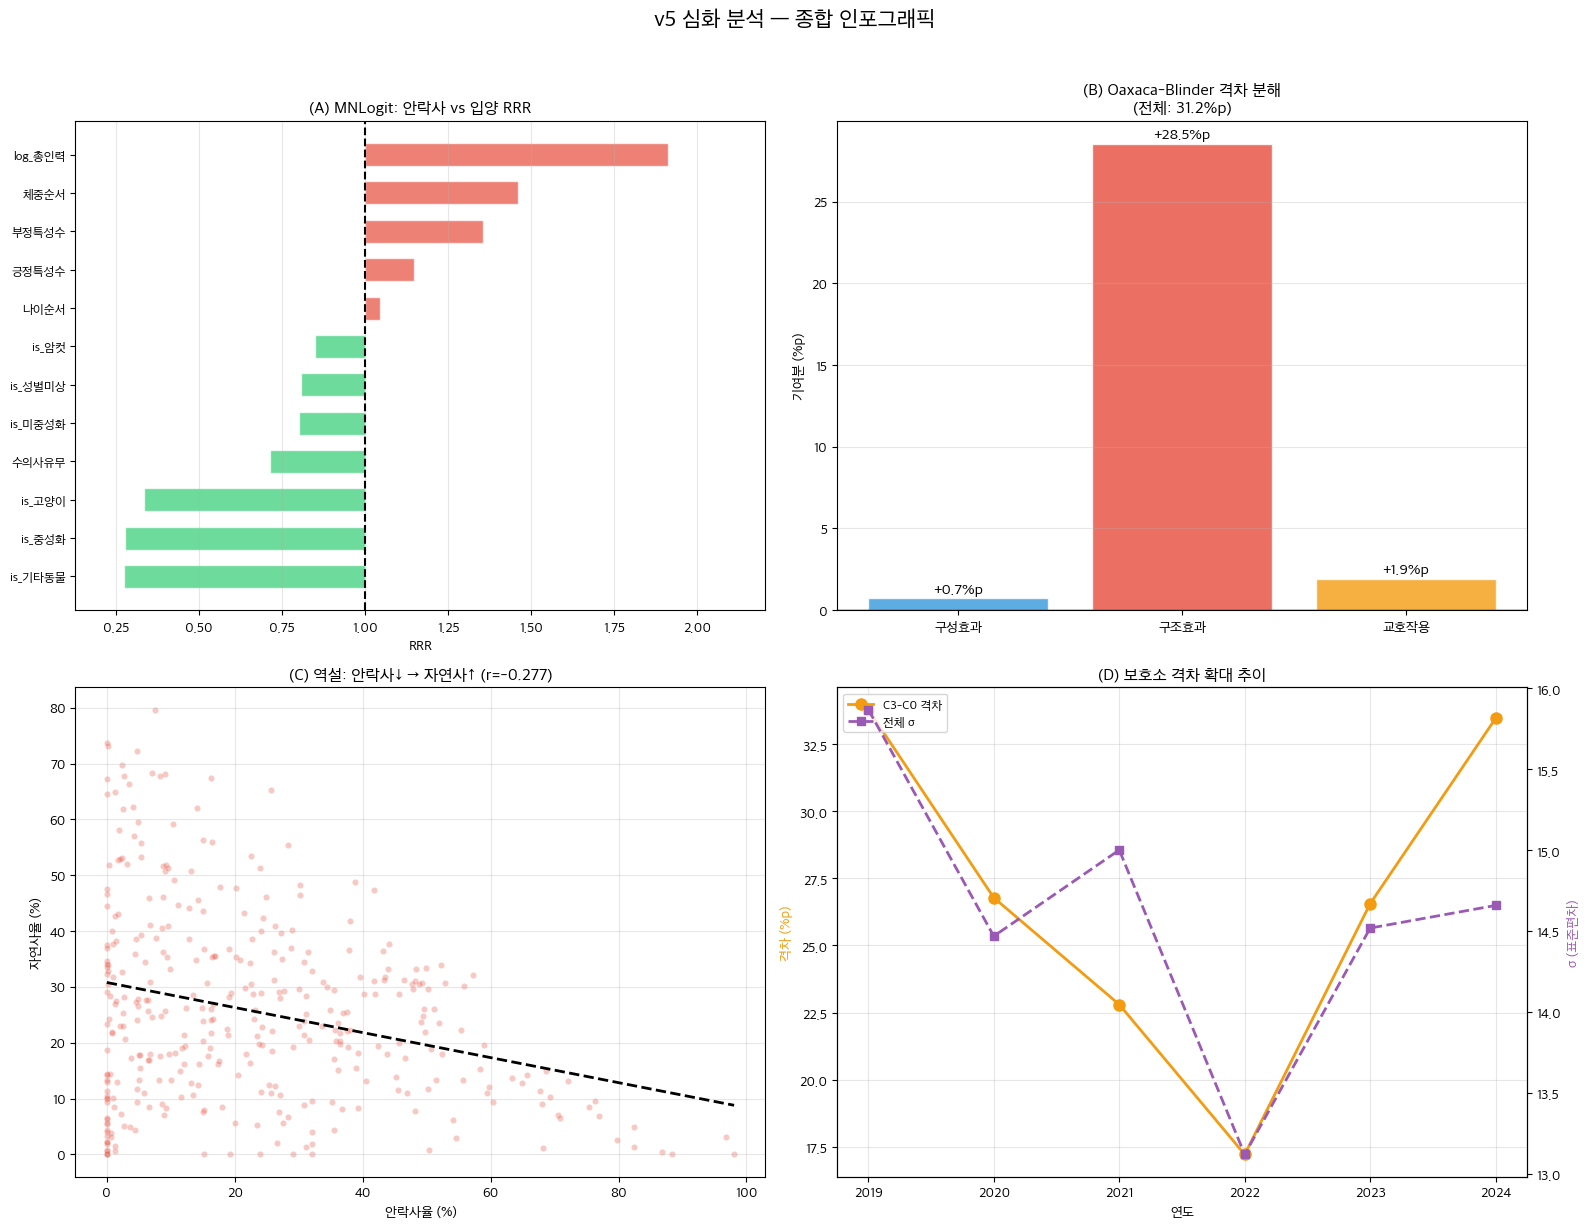

저장: summary_infographic.png


In [34]:
# ── 셀 42: 4패널 종합 인포그래픽 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) MNLogit RRR — 안락사 vs 입양
ax = axes[0, 0]
sub_rrr = df_rrr[df_rrr['비교'] == '안락사 vs 입양'].sort_values('RRR')
y_pos = np.arange(len(sub_rrr))
colors_rrr = ['#e74c3c' if r > 1 else '#2ecc71' for r in sub_rrr['RRR'].values]
ax.barh(y_pos, sub_rrr['RRR'].values - 1, left=1, color=colors_rrr, alpha=0.7,
         edgecolor='white', height=0.6)
ax.axvline(1, color='black', linewidth=1.5, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(sub_rrr['변수'].values, fontsize=9)
ax.set_xlabel('RRR')
ax.set_title('(A) MNLogit: 안락사 vs 입양 RRR', fontsize=12, fontweight='bold')
ci_max_a = sub_rrr['95%CI_상'].quantile(0.95)
ax.set_xlim(max(0.01, sub_rrr['95%CI_하'].min() * 0.5), min(ci_max_a * 1.3, 8))
ax.grid(axis='x', alpha=0.3)

# (2) Oaxaca-Blinder 3분해
ax = axes[0, 1]
decomp_vals = [total_endowment*100, total_coefficient*100, total_interaction*100]
decomp_labels = ['구성효과', '구조효과', '교호작용']
decomp_colors = ['#3498db', '#e74c3c', '#f39c12']
bars = ax.bar(decomp_labels, decomp_vals, color=decomp_colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, decomp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val > 0 else -0.3),
            f'{val:+.1f}%p', ha='center', fontsize=11, fontweight='bold')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('기여분 (%p)')
ax.set_title(f'(B) Oaxaca-Blinder 격차 분해\n(전체: {total_gap*100:.1f}%p)',
              fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (3) 역설 — 안락사율 vs 자연사율
ax = axes[1, 0]
ax.scatter(shelter_rates['안락사률'], shelter_rates['자연사율'],
           alpha=0.3, s=20, c='#e74c3c', edgecolors='white', linewidth=0.3)
z_line = np.polyfit(shelter_rates['안락사률'], shelter_rates['자연사율'], 1)
x_l = np.linspace(shelter_rates['안락사률'].min(), shelter_rates['안락사률'].max(), 100)
ax.plot(x_l, np.polyval(z_line, x_l), '--', color='black', linewidth=2)
ax.set_xlabel('안락사율 (%)')
ax.set_ylabel('자연사율 (%)')
ax.set_title(f'(C) 역설: 안락사↓ → 자연사↑ (r={r_ns:.3f})', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# (4) σ-발산 추이
ax = axes[1, 1]
if len(df_yearly_gap) > 0:
    ax.plot(df_yearly_gap['연도'], df_yearly_gap['격차'], 'o-',
             color='#f39c12', linewidth=2, markersize=8, label='C3-C0 격차')
    ax2 = ax.twinx()
    ax2.plot(df_yearly_gap['연도'], df_yearly_gap['전체_σ'], 's--',
              color='#9b59b6', linewidth=2, markersize=6, label='전체 σ')
    ax.set_xlabel('연도')
    ax.set_ylabel('격차 (%p)', color='#f39c12')
    ax2.set_ylabel('σ (표준편차)', color='#9b59b6')
    ax.set_title('(D) 보호소 격차 확대 추이', fontsize=12, fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)

plt.suptitle('v5 심화 분석 — 종합 인포그래픽', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'summary_infographic.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장: summary_infographic.png")


In [35]:
# ── 셀 43: 모든 결과 CSV 저장 + 파일 목록 출력 ──

# 최종 확인
print("=" * 80)
print("v5 심화 분석 완료 — 산출물 목록")
print("=" * 80)

# 시각화 파일 확인
expected_figs = [
    'individual_outcome_profile.png',
    'cluster_outcome_mosaic.png',
    'vet_outcome_comparison.png',
    'age_species_outcome.png',
    'shelter_adoption_composition.png',
    'mnlogit_rrr_forest.png',
    'km_curves_by_group.png',
    'cif_vet_comparison.png',
    'cif_cluster_comparison.png',
    'cox_hr_forest.png',
    'oaxaca_waterfall.png',
    'policy_simulation.png',
    'sigma_divergence_tracking.png',
    'paradox_substitute_outcomes.png',
    'summary_infographic.png',
]

print("\n📊 시각화 파일:")
for fig_name in expected_figs:
    fig_path = os.path.join(FIG_DIR, fig_name)
    status = '✓' if os.path.exists(fig_path) else '✗'
    print(f"  [{status}] {fig_name}")

# CSV 파일 확인
expected_csvs = [
    'individual_mnlogit_results.csv',
    'individual_cox_results.csv',
    'oaxaca_decomposition_results.csv',
    'policy_simulation_results.csv',
]

print("\n📄 CSV 파일:")
for csv_name in expected_csvs:
    csv_path = os.path.join(DATA_DIR, csv_name)
    status = '✓' if os.path.exists(csv_path) else '✗'
    print(f"  [{status}] {csv_name}")

print(f"\n총 시각화: {sum(1 for f in expected_figs if os.path.exists(os.path.join(FIG_DIR, f)))}/{len(expected_figs)}")
print(f"총 CSV: {sum(1 for f in expected_csvs if os.path.exists(os.path.join(DATA_DIR, f)))}/{len(expected_csvs)}")
print("\nv5 심화 분석 노트북 실행 완료!")


v5 심화 분석 완료 — 산출물 목록

📊 시각화 파일:
  [✓] individual_outcome_profile.png
  [✓] cluster_outcome_mosaic.png
  [✓] vet_outcome_comparison.png
  [✓] age_species_outcome.png
  [✓] shelter_adoption_composition.png
  [✓] mnlogit_rrr_forest.png
  [✓] km_curves_by_group.png
  [✓] cif_vet_comparison.png
  [✓] cif_cluster_comparison.png
  [✓] cox_hr_forest.png
  [✓] oaxaca_waterfall.png
  [✓] policy_simulation.png
  [✓] sigma_divergence_tracking.png
  [✓] paradox_substitute_outcomes.png
  [✓] summary_infographic.png

📄 CSV 파일:
  [✓] individual_mnlogit_results.csv
  [✓] individual_cox_results.csv
  [✓] oaxaca_decomposition_results.csv
  [✓] policy_simulation_results.csv

총 시각화: 15/15
총 CSV: 4/4

v5 심화 분석 노트북 실행 완료!
